<a href="https://colab.research.google.com/github/Doctor-Math/TPs-Mineracao-de-Dados/blob/VariableMath/TP1_Fase2_Grupo6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Trabalho Prático de Mineração de Dados — Fase 2
## Utilização de LLMs e Análise Comparativa com Diretrizes de IA Responsável

**Disciplina:** Mineração de Dados  
**Grupo:** João Marcos Oliveira Neves (2024008644), Júlia Borba Fonseca de Souza (2023117580), Laura Martins Froede (2023087877), Matheus Soares dos Santos de Freitas (2024080043)
**Dataset:** MovieLens 32M  
**Tarefa de mineração:** Padrões frequentes
**Data da entrega:** 03/05/2026

---

## Objetivo deste notebook

Este notebook documenta a Fase 2 do Trabalho Prático. O objetivo é usar uma ou mais LLMs como apoio à construção da solução de mineração de dados e comparar duas trilhas de interação:

- **Trilha A — baseline:** interação com a LLM sem explicitar diretrizes de IA responsável;
- **Trilha B — guiada:** interação com a LLM explicitando as diretrizes de IA responsável escolhidas pelo grupo.

O foco não é apenas mostrar prompts e respostas. O grupo deve analisar criticamente se a explicitação das diretrizes levou a diferenças concretas na solução proposta, por exemplo em:

- escolha de algoritmos;
- tratamento dos dados;
- seleção de atributos;
- definição de parâmetros;
- métricas de avaliação;
- interpretabilidade;
- privacidade;
- análise de viés;
- custo computacional;
- qualidade da documentação.

> **Importante:** este notebook é um modelo de estrutura. Ele contém exemplos, placeholders e código genérico. O grupo deve substituir os campos indicados por informações reais do seu dataset, das interações com LLMs e dos experimentos efetivamente realizados.


# Como usar este notebook

Este notebook foi organizado seguindo a estrutura esperada para a Fase 2:

1. **Business Understanding**
2. **Data Understanding & Data Preparation**
3. **Modeling**
4. **Evaluation**
5. **Checklist final**

Ao longo do notebook, os trechos marcados entre colchetes, como `[INSERIR LINK DA CONVERSA]`, devem ser preenchidos pelo grupo.

## Diferença entre exemplo e entrega real

- Células de **exemplo** mostram como organizar a entrega.
- Células com **placeholders** indicam pontos que devem ser preenchidos.
- Células de **código** são genéricas e podem precisar de adaptação ao dataset.
- Nenhum resultado experimental deve ser inventado.
- Toda conclusão empírica deve estar apoiada em uma tabela, gráfico ou execução de código.


# 0. Controle da entrega e rastreabilidade

Esta seção registra informações mínimas para tornar o trabalho rastreável e auditável.

| Item | Valor |
|---|---|
| Nome do dataset | MovieLens 32M |
| Link público do dataset | https://grouplens.org/datasets/movielens/ |
| Número de linhas | 32.000.204 (3.200.020 após amostragem estratificada) |
| Número de colunas | 11 (colunas únicas considerando todos os arquivos da base) |
| Tarefa de mineração | Identificação de padrões ocultos de coocorrência em grandes volumes de dados de avaliação de filmes na web |
| LLM usada na Trilha A | Gemini Pro |
| LLM usada na Trilha B | Gemini Pro |
| Link da conversa — Trilha A | https://www.google.com/url?q=https%3A%2F%2Fgemini.google.com%2Fshare%2F4d0aa5f7f959 |
| Link da conversa — Trilha B | https://www.google.com/url?q=https%3A%2F%2Fgemini.google.com%2Fshare%2Fca1eab2704a9 |

## Diretrizes de IA responsável escolhidas

| Diretriz | Justificativa da escolha | Como será explicitada na Trilha B |
|---|---|---|
| Explicabilidade | O objetivo é transformar métricas técnicas e IDs abstratos em informações compreensíveis. Em sistemas de recomendação baseados em regras de associação, isso significa cruzar dados (como gêneros e tags) para fornecer uma justificativa semântica para cada sugestão. | "Atue como um analista de negócios. Para cada regra de associação extraída, você não deve apenas listar IDs e métricas; você deve cruzar os dados com os arquivos movies.csv e tags.csv para traduzir o padrão técnico em uma justificativa semântica clara (ex: correlacionar gêneros ou estéticas visuais comuns)." |
| Eficiência e Escalabilidade | Foca na viabilidade técnica ao lidar com grandes volumes de dados (Big Data), como a base MovieLens. Busca evitar a "explosão combinatória" de algoritmos (ex: FP-Growth), garantindo que o sistema seja rápido e econômico em termos de hardware. | "Atue como um Arquiteto de Dados focado em alta performance. Ao gerar scripts de manipulação de dados para a base MovieLens, você deve priorizar a vetorização de operações e a otimização de tipos primitivos (ex: converter strings repetitivas em category e IDs em int32). Além disso, sugira critérios de poda de suporte mínimo que garantam a execução do modelo em hardware acadêmico padrão sem perda de representatividade estatística." |

> **Propósito pedagógico:** esta seção evita que a análise fique solta ou apenas narrativa. O avaliador precisa conseguir identificar o que foi perguntado à LLM, quando, em qual modelo e com qual objetivo.


In [ ]:
# Configurações iniciais do notebook
# Esta célula centraliza imports e parâmetros gerais.
# O grupo deve adaptar os caminhos, nomes de colunas e tipo de tarefa.

import os
import time
import json
import warnings
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# from google.colab import drive
# drive.mount("/content/drive")

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# Caminho para o dataset.
# Exemplos:
# DATA_PATH = "dados/dataset.csv"
# DATA_PATH = "/content/dataset.csv"
DATA_PATH = "dados_combinados.csv"

# Tipo de tarefa do TP.
# Opções sugeridas:
# - "padroes_frequentes"
# - "agrupamento"
# - "classificacao"
TASK_TYPE = "padroes_frequentes"

# Coluna-alvo, se aplicável.
# Para padrões frequentes ou agrupamento, normalmente pode ser None.
TARGET_COLUMN = None  # Exemplo: "classe"

# Coluna ou conjunto de colunas usadas para gerar transações, se o TP for de padrões frequentes.
TRANSACTION_COLUMN = ["userId", "movieId"]

print("Configuração carregada.")
print(f"Tarefa definida: {TASK_TYPE}")


Configuração carregada.
Tarefa definida: padroes_frequentes


# 1. Business Understanding

Nesta seção, o grupo deve explicar o problema, o contexto dos dados, a relevância da tarefa e a hipótese experimental sobre o uso das diretrizes de IA responsável.

A seção deve responder:

1. Qual problema será investigado?
2. Por que o dataset é relevante?
3. Qual tarefa de mineração de dados será executada?
4. Qual é o valor esperado da análise?
5. Quais diretrizes de IA responsável foram escolhidas?
6. Por que essas diretrizes são pertinentes ao problema?
7. O que se espera que mude quando essas diretrizes são explicitadas à LLM?


## 1.1 Descrição do problema de negócio

- **Contexto:** No atual cenário das plataformas de streaming, a retenção de usuários depende da capacidade de oferecer conteúdo relevante em catálogos que superam dezenas de milhares de títulos. Embora algoritmos de Deep Learning dominem a predição de notas, eles operam como "caixas-pretas", oferecendo pouca transparência sobre as associações semânticas que unem os itens.
- **Problema:** A falta de interpretabilidade nas recomendações dificulta a curadoria estratégica do catálogo e a criação de campanhas de marketing personalizadas. O problema central é identificar padrões de coocorrência (quais filmes ou gêneros são consumidos juntos) que revelem a lógica por trás das "comunidades de gosto" dos usuários, indo além da simples predição numérica.
- **Possíveis interessados:**
- - Gestores de Produto: para otimização da interface de usuário e criação de novas categorias;
  - Curadores de Conteúdo: para entender quais títulos do catálogo histórico (backlog) possuem sinergia com lançamentos atuais;
  - Equipes de Marketing: para desenhar campanhas de recomendação baseadas em nichos de comportamento específicos.
- **Decisões apoiadas pela análise:** Agrupamento de filmes em novas subcategorias híbridas na interface (ex: "Clássicos que inspiraram o Cinema Moderno"); seleção de títulos para licenciamento ou renovação de contrato baseada em padrões de consumo frequente; criação de bundles ou sugestões do tipo "Você também pode gostar" baseadas em regras de associação com alto Lift.
- **Limitações iniciais conhecidas:**
- - Esparsidade: A matriz usuário-filme é altamente esparsa, o que exige filtros rigorosos de suporte para evitar regras triviais ou irrelevantes;
  - Volume de Dados: O processamento de 32 milhões de registros exige estratégias de amostragem e otimização de memória para execução em ambiente local;
  - Frequência de Tags: Metadados gerados por usuários (tags) podem conter ruídos, exigindo limpeza para que a análise semântica faça sentido.


## 1.2 Objetivo do dataset, origem e características gerais

### Objetivo do dataset

O propósito do dataset é fornecer um registro histórico massivo de interações entre usuários e filmes, permitindo a pesquisa em sistemas de recomendação, filtragem colaborativa e mineração de padrões de consumo. Ele serve para entender as preferências de audiência e a evolução do gosto cinematográfico ao longo de quase três décadas.

### Origem dos dados

Os dados foram coletados e são mantidos pelo GroupLens Research, um laboratório de pesquisa da Universidade de Minnesota. O dataset MovieLens é o padrão ouro na literatura acadêmica de sistemas de recomendação.

Link público: https://grouplens.org/datasets/movielens/32m/

### Características do dataset

| Coluna | Tipo esperado | Descrição | Relevância para a tarefa |
|---|---|---|---|
| userId | Inteiro (int32) | Identificador único e anonimizado do usuário. | Essencial para agrupar as "cestas de compras" (transações). |
| movieId | Inteiro (int32) | Identificador único do filme. | Item principal da regra de associação (A→B). |
| rating | Float (float32) | Nota de 0.5 a 5.0 atribuída ao filme. | Usada para filtrar apenas as "preferências positivas" (≥4.0). |
| genres | String/Binarizado | Gêneros associados ao filme (ex: Action, Sci-Fi). | Base para a Hipótese 1 (Sinergia de Gêneros). |
| title | String | Título do filme e ano de lançamento. | Fonte para a Hipótese 3 (Engenharia de Atributos de Eras). |

### Relação com o problema de negócio

Este dataset é ideal para o problema escolhido por três motivos principais:

    Escala: Com 3,2 milhões de avaliações (versão amostrada), permite encontrar regras com suporte estatístico mesmo para nichos de filmes menos populares (Cauda Longa).

    Riqueza de Metadados: A presença de gêneros e o ano de lançamento no título permitem testar a sinergia entre categorias e eras cinematográficas.

    Realismo: Por ser uma base de usuários reais em um ambiente de produção, os padrões de coocorrência extraídos refletem comportamentos de consumo verdadeiros, e não simulados, validando a aplicação prática da análise para curadoria e marketing.


## 1.3 Diretrizes selecionadas e hipótese experimental

### Diretrizes selecionadas

| Diretriz | Por que é pertinente ao problema? | Possível efeito esperado na solução da LLM |
|---|---|---|
| Explicabilidade | Regras de associação entre IDs numéricos são abstratas. É preciso converter padrões técnicos em justificativas semânticas para curadores de conteúdo. | A LLM deixará de apenas listar regras e passará a cruzar metadados (gêneros/tags) para rotular perfis de consumo e explicar o "porquê" da conexão. |
| Eficiência e Escalabilidade | O processamento de 3,2M de linhas em ambiente local (16GB RAM) exige algoritmos e estruturas de dados otimizados para evitar estouro de memória e tempo excessivo de CPU. | A LLM sugerirá o uso de processamento distribuído ou em chunks (Dask/PySpark), otimização de tipos de dados (dtypes) e algoritmos de passo único como o FP-Growth. |

### Hipótese experimental

Esperamos que, ao explicitar as diretrizes de Explicabilidade e Eficiência e Escalabilidade, a LLM proponha uma solução com alto desempenho computacional e clareza interpretativa, recomendando o uso de bibliotecas de processamento paralelo e a compressão de dados via FP-Tree, garantindo que a descoberta de padrões seja tecnicamente viável em hardware limitado sem sacrificar a riqueza semântica dos resultados, em comparação com uma solução baseline que poderia sugerir métodos ineficientes (como o Apriori clássico) ou saídas puramente numéricas.

### Evidências que serão analisadas

Para avaliar a hipótese, compararemos as trilhas quanto a:

- algoritmos sugeridos;
- etapas de preparação dos dados;
- parâmetros recomendados;
- métricas propostas;
- justificativas técnicas;
- riscos apontados;
- limitações reconhecidas;
- aderência às diretrizes escolhidas.


## 1.4 Interações com LLM — Business Understanding

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 03/05/2026
**Link da conversa:** https://gemini.google.com/share/4d0aa5f7f959
**Subtarefa:** obter apoio para formular o Business Understanding.

#### Prompt principal — baseline

```text
Atue como um Especialista em Ciência de Dados e Consultor de Negócios. Estou desenvolvendo um projeto de Mineração de Dados utilizando o dataset MovieLens 32M (ml-32m), que foi estratificada numa amostra para de tamanho de 3,2 milhões de linhas.

A tarefa principal é a Mineração de Padrões Frequentes e Regras de Associação para identificar coocorrência de filmes e atributos (gêneros e eras), visando otimizar a curadoria de catálogos de streaming e estratégias de marketing.

Ajude-me a formular o Business Understanding, incluindo objetivo do dataset,
origem dos dados, características gerais e relação com o problema.
```

#### Síntese da resposta da LLM

Entendimento do Negócio (Business Understanding)

1. Contexto e Relação com o Problema de Negócio
No mercado altamente competitivo de plataformas de streaming, a retenção de usuários e o engajamento contínuo são os principais motores de receita. O desafio central é evitar o churn (cancelamento) provocado pela fadiga de decisão do usuário.

A aplicação de Mineração de Padrões Frequentes e Regras de Associação resolve este problema ao descobrir relações ocultas e não triviais no comportamento de consumo. O objetivo não é apenas recomendar o óbvio (ex: "quem assistiu o filme A, assistiu a continuação B"), mas identificar coocorrências complexas entre filmes, gêneros e eras de lançamento.

Esses insights suportam diretamente duas frentes de negócios:

    Curadoria de Catálogo: Auxilia a área de aquisição de conteúdo a entender quais nichos e combinações de atributos (ex: Sci-Fi dos anos 90 associado a Thrillers Psicológicos) mantêm os usuários na plataforma, otimizando o ROI sobre o licenciamento de obras.

    Estratégias de Marketing: Permite o desenho de campanhas direcionadas, criação de trilhas de consumo customizadas (ex: "Coleções que você vai amar") e cross-selling de produções originais para públicos com padrões de consumo específicos.

2. Origem dos Dados
Os dados são provenientes do MovieLens, uma das bases mais prestigiadas e confiáveis do mundo para pesquisa em sistemas de recomendação, mantida pelo GroupLens Research, um laboratório do Departamento de Ciência da Computação e Engenharia da Universidade de Minnesota. O conjunto de dados original é gerado a partir de avaliações reais feitas por usuários na plataforma online MovieLens desde 1995, garantindo que os dados reflitam comportamentos de consumo orgânicos e ao longo de um extenso período histórico.

3. Objetivo do Dataset
O principal objetivo da base MovieLens é fornecer insumos estruturados (interações usuário-item, metadados de obras e tags) para o avanço da ciência de dados, aprendizado de máquina e mineração de dados. Neste projeto específico, o dataset servirá como a "verdade fundamental" (ground truth) para mapear transações de consumo. Ao transformar o histórico de avaliações positivas de um usuário em uma "cesta de consumo", podemos aplicar algoritmos de mineração para extrair regras do tipo: {Gênero: Ação, Era: Anos 80} -> {Gênero: Aventura, Confiança: 85%}.

4. Características Gerais dos Dados
O projeto utiliza uma amostra estratificada e representativa de 10% do dataset MovieLens 32M original, totalizando 3,2 milhões de interações. O ecossistema de dados está distribuído de forma relacional (geralmente em arquivos .csv) e apresenta as seguintes características-chave necessárias para a modelagem:

    Dimensionalidade: Requer cruzamento de entidades distintas. A tabela principal de interações (usuário, filme, avaliação, timestamp) precisa ser enriquecida com metadados dos filmes (título, gêneros).

    Engenharia de Atributos: O dado bruto não possui a variável "Era". Será necessário um processo de transformação de dados para extrair o ano de lançamento dos títulos ou metadados e categorizá-los em décadas/eras de forma programática.

    Esparsidade: Como é característico de matrizes de recomendação, um usuário médio consome apenas uma fração minúscula do catálogo total, tornando a extração de itemsets frequentes um desafio técnico que exige algoritmos otimizados para dados esparsos.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 03/05/2026
**Link da conversa:** https://gemini.google.com/share/ca1eab2704a9
**Subtarefa:** obter apoio para formular o Business Understanding considerando as diretrizes escolhidas.

#### Prompt principal — guiado

```text
Atue como um Especialista em Ciência de Dados e Consultor de Negócios. Estou desenvolvendo um projeto de Mineração de Dados utilizando o dataset MovieLens 32M (ml-32m), que foi estratificada numa amostra para de tamanho de 3,2 milhões de linhas.

A tarefa principal é a Mineração de Padrões Frequentes e Regras de Associação para identificar coocorrência de filmes e atributos (gêneros e eras), visando otimizar a curadoria de catálogos de streaming e estratégias de marketing.

Ajude-me a formular a fase de 'Business Understanding' e o planejamento da solução, considerando explicitamente as seguintes diretrizes de IA Responsável:

1. EXPLICABILIDADE: O sistema de recomendação não deve ser uma "caixa-preta". As regras de associação geradas (A -> B) devem ser interpretáveis. Explique como traduzir os IDs numéricos e métricas (Support, Confidence, Lift) em justificativas semânticas claras para curadores humanos.

2. EFICIÊNCIA E ESCALABILIDADE: O dataset possui 32 milhões de registros e o processamento será feito em ambiente local com 16GB de RAM. Proponha estratégias técnicas (como otimização de tipos de dados, amostragem estratificada e algoritmos de passo único como FP-Growth) para garantir que a mineração seja concluída sem estouro de memória e em tempo hábil.

Além da descrição do problema, indique riscos técnicos, limitações da abordagem de itemsets estáticos e os critérios de sucesso (KPIs) que deveriam orientar esta solução de mineração de dados.
```

#### Síntese da resposta da LLM

### Síntese da resposta da LLM
Fase 1: Business Understanding (Compreensão do Negócio)
Objetivo Central: Transformar padrões ocultos de consumo de filmes em estratégias acionáveis para a curadoria de catálogos e marketing de plataformas de streaming, utilizando regras de associação extraídas de uma amostra do MovieLens 32M.

Desafio de Negócio: Curadores humanos e equipes de marketing precisam de insights interpretáveis para tomar decisões estratégicas, criar campanhas de e-mail marketing segmentadas ou adquirir licenças de filmes que possuem alta sinergia com o catálogo atual, reduzindo a dependência de modelos "caixa-preta".

Fase 2: IA Responsável e Explicabilidade
Para garantir que o sistema não seja uma "caixa-preta", a entrega final deve traduzir a matemática pura em narrativas de negócio.Para uma regra $A \rightarrow B$, a tradução semântica para os curadores deve seguir este padrão:
- Tradução de IDs: JOIN dos IDs numéricos, garantindo que a regra apresente Títulos, Gêneros e Eras.
- Support (Suporte): Isso indica à curadoria se o nicho é grande o suficiente para justificar uma campanha na página inicial.
- Confidence (Confiança): Isso justifica regras de recomendação pós-visualização (o famoso "Porque você assistiu X, assista Y").
- Lift (Sustentação/Alavancagem): Traduza como "Força da Sinergia" (força da relação entre itens).

Fase 3: Eficiência e Escalabilidade (Processamento Local)
- Otimização de Tipos de Dados (Downcasting): Converta IDs de usuários e filmes para int32 ou até int16 se o valor máximo permitir para reduz o consumo de RAM.
- Estruturas Esparsas: Utilize matrizes esparsas, que armazenam apenas os valores não nulos.
- Amostragem Estratificada e Chunking: Se a leitura do CSV estourar a memória, leia o arquivo em pedaços (chunks) ou utilize bibliotecas como Polars ou DuckDB.
- Algoritmo FP-Growth: Evite o algoritmo Apriori tradicional. Utilize o FP-Growth, que comprime o dataset em uma estrutura de árvore (FP-Tree) com apenas duas passagens pelos dados, tornando o processo ordens de grandeza mais rápido e eficiente em memória.

Fase 4: Riscos Técnicos e Limitações
- Viés de Popularidade (Popularity Bias): Blockbusters terão um suporte altíssimo, dominando as regras e ofuscando conexões interessantes em filmes de nicho.
- Falta de Dinâmica Temporal: Regras estáticas ignoram a evolução do gosto do usuário e a sazonalidade.
- Problema do Cold Start: Filmes recém-adicionados ao catálogo não terão histórico de transações, impossibilitando que o algoritmo gere regras de associação para eles.

Fase 5: Critérios de Sucesso (KPIs)
- KPIs Técnicos:
  - Pico de consumo de memória RAM restrito a no máximo 12GB (deixando margem para o sistema operacional).
  - Tempo de execução da geração da FP-Tree inferior a 15 minutos na amostra de 3,2M
- KPIs de Negócio (Curadoria):
  - Identificação de pelo menos 50 regras de associação de cauda longa (filmes de nicho) com Lift $> 2.0$ e Confidence $> 0.5$.
  - Taxa de usabilidade: Percentual das regras geradas que os curadores humanos consideram "surpreendentes e acionáveis" (medido via validação qualitativa).


## 1.5 Análise crítica das trilhas — Business Understanding

| Critério | Trilha A — baseline | Trilha B — guiada | Diferença observada |
|---|---|---|---|
| Clareza do problema | Apresenta bem o contexto de streaming, curadoria e marketing, mas de forma mais geral. | Define o problema de forma mais orientada à solução, destacando o uso humano das regras geradas. | A Trilha B é mais clara por conectar o problema aos requisitos práticos da solução. |
| Relação com o dataset | Descreve melhor a origem do MovieLens, sua estrutura relacional, os metadados e a criação da variável “Era”. | Relaciona o dataset às restrições de processamento e à necessidade de transformar regras em explicações interpretáveis. | A Trilha A é melhor na descrição do dataset; a Trilha B é melhor na ligação com a solução. |
| Consideração das diretrizes | Não trata explicitamente IA Responsável, explicabilidade ou eficiência. | Considera explicabilidade, eficiência e escalabilidade de forma direta. | A Trilha B apresenta melhoria concreta por seguir as diretrizes propostas. |
| Identificação de riscos | Menciona desafios técnicos, como esparsidade, mas não discute riscos metodológicos de forma clara. | Aponta viés de popularidade, ausência de dinâmica temporal e problema de cold start. | A Trilha B é superior por identificar riscos relevantes para a abordagem. |
| Qualidade da justificativa | Justifica o uso de regras de associação para curadoria e marketing, mas sem métricas de validação. | Propõe KPIs técnicos e de negócio, como uso de RAM, tempo de execução, lift, confidence e validação por curadores. | A Trilha B tem justificativa mais rastreável e avaliável. |
| Erros ou omissões | Não apresenta critérios de sucesso, riscos específicos nem plano de escalabilidade. Também repete parte da resposta. | Ainda precisa justificar melhor os valores sugeridos para os KPIs, que parecem hipóteses iniciais. | A Trilha B reduz omissões importantes, mas os KPIs devem ser validados experimentalmente. |

### Síntese crítica

A Trilha B deve ser considerada melhor que a Trilha A, pois apresenta evidências concretas de melhoria. Enquanto a baseline formula bem o contexto geral do problema e descreve adequadamente o dataset MovieLens, ela permanece mais descritiva e não explicita riscos, critérios de sucesso ou diretrizes de IA Responsável.

A resposta guiada avança ao incorporar explicabilidade, eficiência e escalabilidade ao Business Understanding. Ela propõe traduzir IDs, métricas e regras de associação em justificativas compreensíveis para curadores humanos, além de sugerir estratégias técnicas como downcasting, estruturas esparsas, chunking e uso de FP-Growth.

Também há melhoria na identificação de limitações metodológicas, como viés de popularidade, ausência de dinâmica temporal e cold start. Esses pontos tornam a análise mais crítica e mais alinhada ao planejamento real de uma solução de mineração de dados.

Apesar disso, os KPIs sugeridos na Trilha B devem ser tratados como hipóteses iniciais, pois precisam ser confirmados empiricamente durante os experimentos. Assim, a melhor versão final deve combinar a boa descrição do dataset feita na Trilha A com os riscos, critérios de avaliação e diretrizes práticas apresentados na Trilha B.

# 2. Data Understanding & Data Preparation

Nesta seção, o grupo deve explorar o dataset, identificar problemas de qualidade dos dados e preparar os dados para a etapa de modelagem.

Além disso, deve registrar como a LLM foi usada para apoiar:

- exploração inicial;
- identificação de problemas;
- tratamento de valores ausentes;
- transformação de atributos;
- seleção de variáveis;
- preparação específica para a tarefa de mineração;
- identificação de aspectos relacionados às diretrizes de IA responsável.


In [ ]:
# from google.colab import drive
# drive.mount("/content/drive")

In [ ]:
# !find "/content/drive/MyDrive" -name "ratings_amostra.csv"

In [ ]:
DATA_PATH = "dados_combinados.csv"

In [ ]:
# Carregamento do dataset
# Esta célula deve ser adaptada de acordo com o formato do arquivo.

def carregar_dataset(caminho: str) -> pd.DataFrame:
    # Carrega um dataset a partir de um arquivo CSV, Excel, JSON ou Parquet.
    # Adapte esta função se o dataset estiver em outro formato.
    if caminho == "[INSERIR_CAMINHO_DO_ARQUIVO]":
        raise ValueError("Substitua DATA_PATH pelo caminho real do dataset.")

    caminho_path = Path(caminho)

    if not caminho_path.exists():
        raise FileNotFoundError(f"Arquivo não encontrado: {caminho}")

    if caminho_path.suffix.lower() == ".csv":
        return pd.read_csv(caminho_path)
    elif caminho_path.suffix.lower() in [".xlsx", ".xls"]:
        return pd.read_excel(caminho_path)
    elif caminho_path.suffix.lower() == ".json":
        return pd.read_json(caminho_path)
    elif caminho_path.suffix.lower() == ".parquet":
        return pd.read_parquet(caminho_path)
    else:
        raise ValueError("Formato não tratado neste modelo. Adapte a função carregar_dataset.")

# Exemplo de uso:
df = carregar_dataset(DATA_PATH)
print("Dataset carregado com sucesso.")
print(f"Número de linhas: {df.shape[0]}")
print(f"Número de colunas: {df.shape[1]}")
display(df.head())


Dataset carregado com sucesso.
Número de linhas: 3188400
Número de colunas: 6


,userId,movieId,rating,timestamp,title,genres
0,1,17,4.0,944249077,Sense and Sensibility (1995),Drama|Romance
1,1,25,1.0,944250228,Leaving Las Vegas (1995),Drama|Romance
2,1,29,2.0,943230976,"City of Lost Children, The (Cité des enfants p...",Adventure|Drama|Fantasy|Mystery|Sci-Fi
3,1,30,5.0,944249077,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1,32,5.0,943228858,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller


In [ ]:
# Verificação mínima das restrições do dataset
# A especificação exige dataset público, com pelo menos 1000 linhas e 4 colunas.
# O link público deve ser documentado em Markdown; aqui validamos apenas dimensões.

def verificar_restricoes_dataset(df: pd.DataFrame) -> None:
    n_linhas, n_colunas = df.shape

    print("Verificação das dimensões do dataset")
    print(f"- Linhas: {n_linhas}")
    print(f"- Colunas: {n_colunas}")

    if n_linhas < 1000:
        print("ATENÇÃO: o dataset possui menos de 1000 linhas.")
    else:
        print("OK: o dataset possui pelo menos 1000 linhas.")

    if n_colunas < 4:
        print("ATENÇÃO: o dataset possui menos de 4 colunas.")
    else:
        print("OK: o dataset possui pelo menos 4 colunas.")

# Executar após carregar o dataset:
verificar_restricoes_dataset(df)


Verificação das dimensões do dataset
- Linhas: 3188400
- Colunas: 6
OK: o dataset possui pelo menos 1000 linhas.
OK: o dataset possui pelo menos 4 colunas.


In [ ]:
# Exploração inicial
# Esta célula gera uma visão geral do dataset.
# O grupo deve interpretar os resultados em uma célula Markdown logo abaixo.

def resumo_inicial(df: pd.DataFrame) -> pd.DataFrame:
    resumo = pd.DataFrame({
        "tipo": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "perc_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(dropna=True)
    })

    return resumo.sort_values(by="perc_nulos", ascending=False)

# Exemplo de uso:
resumo = resumo_inicial(df)
display(resumo)


,tipo,n_nulos,perc_nulos,n_unicos
userId,int64,0,0.0,20094
movieId,int64,0,0.0,39708
rating,float64,0,0.0,10
timestamp,int64,0,0.0,2680652
title,object,0,0.0,39650
genres,object,0,0.0,1516


In [ ]:
# Estatísticas descritivas
# O objetivo é separar análise de variáveis numéricas e categóricas.

def estatisticas_descritivas(df: pd.DataFrame):
    numericas = df.select_dtypes(include=np.number)
    categoricas = df.select_dtypes(exclude=np.number)

    print("Colunas numéricas:", list(numericas.columns))
    print("Colunas não numéricas:", list(categoricas.columns))

    if len(numericas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis numéricas")
        display(numericas.describe().T)

    if len(categoricas.columns) > 0:
        print("\nEstatísticas descritivas — variáveis categóricas/textuais")
        display(categoricas.describe().T)

# Exemplo de uso:
estatisticas_descritivas(df)


Colunas numéricas: ['userId', 'movieId', 'rating', 'timestamp']
Colunas não numéricas: ['title', 'genres']

Estatísticas descritivas — variáveis numéricas


,count,mean,std,min,25%,50%,75%,max
userId,3188400.0,1.010955e+05,5.732658e+04,1.0,5.305300e+04,1.016390e+05,1.493040e+05,2.009480e+05
movieId,3188400.0,2.948798e+04,5.111971e+04,1.0,1.234000e+03,3.479000e+03,4.497200e+04,2.927570e+05
rating,3188400.0,3.545855e+00,1.050146e+00,0.5,3.000000e+00,3.500000e+00,4.000000e+00,5.000000e+00
timestamp,3188400.0,1.278143e+09,2.558962e+08,822873600.0,1.054595e+09,1.276221e+09,1.506299e+09,1.697156e+09



Estatísticas descritivas — variáveis categóricas/textuais


,count,unique,top,freq
title,3188400,39650,"Shawshank Redemption, The (1994)",10353
genres,3188400,1516,Drama,224187


## 2.1 Exploração inicial — interpretação

A exploração inicial mostra que o dataset carregado possui **3.188.400 linhas** e **6 colunas**. As colunas observadas são `userId`, `movieId`, `rating`, `timestamp`, `title` e `genres`. Esse volume confirma que a base é grande o suficiente para a tarefa de mineração de padrões frequentes, mas também exige cuidado com desempenho e uso de memória.

Em relação aos tipos de atributos, as variáveis `userId`, `movieId` e `timestamp` são numéricas inteiras, enquanto `rating` é numérica contínua. As colunas `title` e `genres` aparecem no carregamento inicial como atributos textuais/categóricos, embora na verificação automática de tipos tenham sido listadas apenas as colunas numéricas. Isso indica que a análise estatística descritiva foi aplicada somente às variáveis numéricas.

Não foram identificados valores ausentes nas colunas avaliadas. Para `userId`, `movieId`, `rating` e `timestamp`, o percentual de nulos foi de **0%**, o que é positivo para a continuidade da análise, pois reduz a necessidade inicial de tratamento de dados faltantes nessas variáveis.

Algumas variáveis possuem muitos valores distintos. A coluna `userId` possui **20.094 usuários únicos**, enquanto `movieId` possui **39.708 filmes únicos**. A coluna `timestamp` apresenta **2.680.652 valores distintos**, o que indica alta granularidade temporal. Essas variáveis são importantes para reconstruir interações usuário-filme, mas também aumentam a cardinalidade do problema.

As colunas `userId` e `movieId` funcionam como identificadores. O `userId` identifica usuários de forma pseudonimizada e o `movieId` identifica filmes. Embora não haja nomes, e-mails ou dados diretamente pessoais, o `userId` ainda deve ser tratado com cautela, pois representa padrões individuais de avaliação. Não foram observados atributos sensíveis explícitos, como gênero, idade, raça, localização ou renda dos usuários.

Para a tarefa de mineração de padrões frequentes e regras de associação, as variáveis mais relevantes são `userId`, `movieId`, `rating`, `title` e `genres`. O `userId` pode ser usado para agrupar as avaliações em “cestas” de consumo; o `movieId` e o `title` representam os itens; o `rating` pode ser usado para filtrar apenas avaliações positivas; e `genres` permite criar regras baseadas em atributos dos filmes. O `timestamp` pode ser útil para análises temporais, mas não é indispensável para uma mineração inicial de itemsets estáticos.

Uma limitação inicial é que a base contém avaliações, não necessariamente consumo real dos filmes. Além disso, a alta cardinalidade de usuários, filmes e timestamps pode aumentar o custo computacional da mineração. Outra limitação é que gêneros aparecem combinados em uma única string separada por `|`, exigindo transformação antes de serem usados adequadamente na mineração. Também será necessário extrair ou padronizar a era dos filmes a partir do título ou de outro metadado, pois essa variável não aparece diretamente como coluna estruturada.

### Relação com as diretrizes escolhidas

A exploração inicial se relaciona diretamente com a diretriz de **Eficiência e Escalabilidade**, pois o dataset possui mais de **3 milhões de registros** e dezenas de milhares de usuários e filmes distintos. Esse volume exige estratégias como otimização de tipos de dados, uso de estruturas esparsas, filtragem por avaliações relevantes e escolha de algoritmos eficientes, como FP-Growth, para evitar alto consumo de memória.

Também há relação com a diretriz de **Explicabilidade**. As colunas `title` e `genres` tornam as regras mais interpretáveis, pois permitem traduzir associações baseadas em IDs numéricos para descrições compreensíveis, como filmes, gêneros e possíveis eras. Sem essa tradução, regras envolvendo apenas `movieId` seriam pouco úteis para curadores humanos.

Do ponto de vista de **Privacidade e Segurança**, não foram identificados atributos sensíveis explícitos. Ainda assim, `userId` representa um identificador pseudonimizado e deve ser usado apenas para agregação de interações, evitando análises individualizadas desnecessárias.

Em relação a **Justiça e Viés**, a exploração inicial ainda não permite avaliar grupos sub-representados, pois não há variáveis demográficas dos usuários. Porém, a alta diferença esperada de popularidade entre filmes pode gerar viés de popularidade, fazendo com que blockbusters dominem os itemsets frequentes e ocultem padrões de nicho. Por isso, etapas futuras devem avaliar a distribuição de avaliações por filme e considerar métricas como suporte, confiança e lift com cuidado.

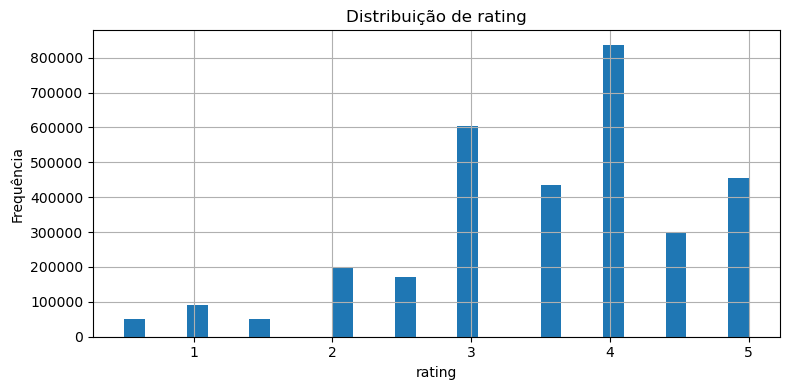

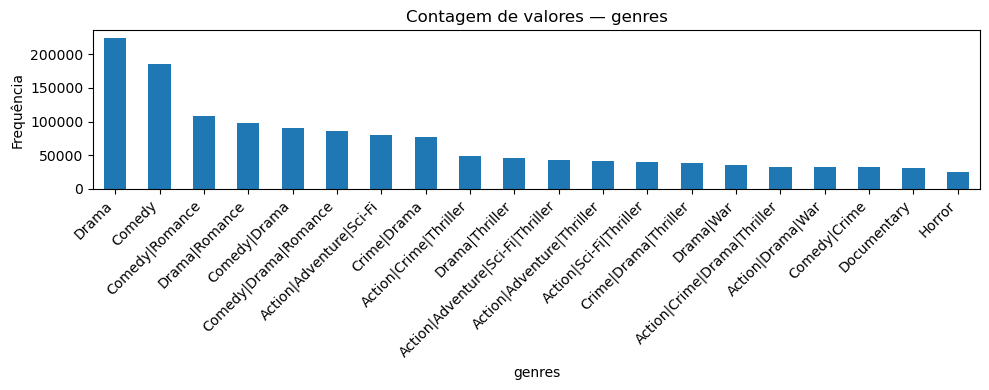

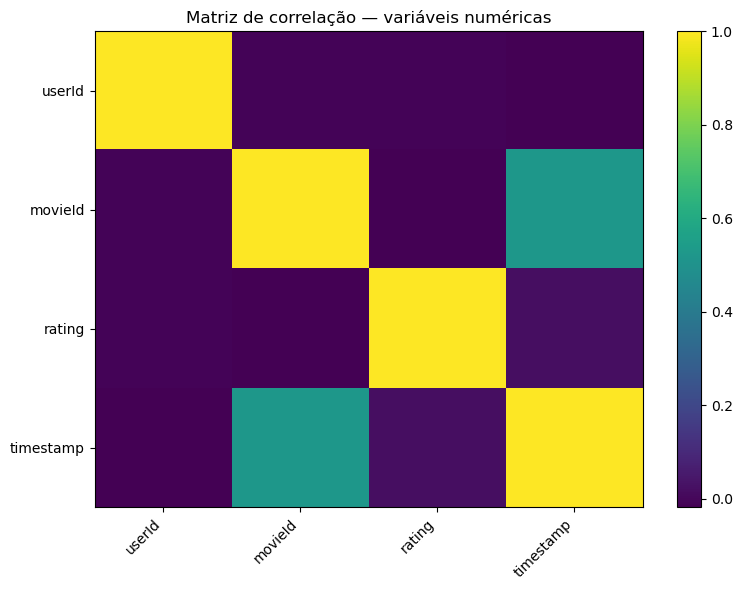

In [ ]:
# Visualizações exploratórias básicas
# O grupo deve adaptar as colunas às características do dataset.

def plot_distribuicao_numerica(df: pd.DataFrame, coluna: str) -> None:
    plt.figure(figsize=(8, 4))
    df[coluna].dropna().hist(bins=30)
    plt.title(f"Distribuição de {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.tight_layout()
    plt.show()

def plot_contagem_categorica(df: pd.DataFrame, coluna: str, top_n: int = 20) -> None:
    plt.figure(figsize=(10, 4))
    df[coluna].value_counts(dropna=False).head(top_n).plot(kind="bar")
    plt.title(f"Contagem de valores — {coluna}")
    plt.xlabel(coluna)
    plt.ylabel("Frequência")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

def plot_matriz_correlacao(df: pd.DataFrame) -> None:
    numericas = df.select_dtypes(include=np.number)

    if numericas.shape[1] < 2:
        print("Não há pelo menos duas variáveis numéricas para calcular correlação.")
        return

    corr = numericas.corr()

    plt.figure(figsize=(8, 6))
    plt.imshow(corr, aspect="auto")
    plt.colorbar()
    plt.xticks(range(len(corr.columns)), corr.columns, rotation=45, ha="right")
    plt.yticks(range(len(corr.columns)), corr.columns)
    plt.title("Matriz de correlação — variáveis numéricas")
    plt.tight_layout()
    plt.show()

# Exemplos de uso:
plot_distribuicao_numerica(df, "rating")
plot_contagem_categorica(df, "genres")
plot_matriz_correlacao(df)


## 2.2 Análise visual — interpretação

A distribuição da variável `rating` mostra concentração de avaliações nas notas mais altas, principalmente em torno de **3.0**, **4.0** e **5.0**, com destaque para a nota **4.0**, que aparece como a mais frequente no gráfico. As notas mais baixas, como **0.5**, **1.0** e **1.5**, aparecem com frequência bem menor. Isso indica um desbalanceamento nas avaliações, com predominância de avaliações positivas ou intermediárias-altas.

Esse padrão é relevante para a mineração de padrões frequentes porque, caso o projeto filtre apenas avaliações positivas, por exemplo `rating >= 4.0`, ainda haverá um volume grande de registros disponíveis. Porém, também existe o risco de que os padrões encontrados representem principalmente filmes bem avaliados e populares, deixando menos visíveis associações envolvendo filmes de nicho ou avaliações negativas.

O gráfico de `genres` mostra forte concentração em algumas categorias. As combinações mais frequentes são **Drama**, **Comedy**, **Comedy|Romance**, **Drama|Romance** e **Comedy|Drama**. Isso sugere que há desbalanceamento entre gêneros: alguns aparecem com frequência muito maior, enquanto outros, como **Horror**, **Documentary** e algumas combinações específicas, aparecem com frequência menor entre os 20 mais frequentes.

Esse desbalanceamento pode afetar diretamente a mineração de itemsets, pois gêneros muito frequentes tendem a gerar regras com suporte alto. Por outro lado, gêneros menos frequentes podem gerar regras mais difíceis de detectar se o suporte mínimo for definido de forma muito alta. Portanto, a escolha dos parâmetros de mineração deve considerar esse desequilíbrio para evitar que apenas categorias dominantes apareçam nos resultados.

A matriz de correlação entre variáveis numéricas não mostra uma relação linear relevante entre `rating` e as demais variáveis numéricas. Isso é esperado, pois `userId` e `movieId` são identificadores numéricos, não variáveis quantitativas com significado ordinal. A correlação mais visível ocorre entre `movieId` e `timestamp`, mas essa relação deve ser interpretada com cautela, pois IDs de filmes não representam uma escala contínua de conteúdo.

Do ponto de vista das diretrizes escolhidas, os gráficos reforçam principalmente a importância de **Eficiência e Escalabilidade** e **Explicabilidade**. O grande volume de avaliações e a concentração em categorias frequentes indicam que a mineração pode gerar muitos padrões redundantes ou dominados por itens populares, exigindo filtros, thresholds adequados e métricas como suporte, confiança e lift. Já a explicabilidade depende de transformar esses padrões em regras compreensíveis, usando nomes dos filmes, gêneros e possíveis eras, em vez de apenas IDs numéricos.

Uma limitação visual importante é que os gráficos apresentados ainda não mostram a distribuição de avaliações por usuário ou por filme. Essas análises seriam úteis para verificar se poucos usuários ou poucos filmes concentram grande parte das interações, o que poderia indicar risco adicional de viés de popularidade na mineração.

In [ ]:
# Detecção simples de outliers em variáveis numéricas usando IQR
# Esta função é um exemplo. O grupo deve avaliar se o critério faz sentido para cada atributo.

def detectar_outliers_iqr(df: pd.DataFrame, coluna: str) -> pd.DataFrame:
    serie = df[coluna].dropna()

    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    outliers = df[(df[coluna] < limite_inferior) | (df[coluna] > limite_superior)]

    print(f"Coluna: {coluna}")
    print(f"Q1: {q1}")
    print(f"Q3: {q3}")
    print(f"IQR: {iqr}")
    print(f"Limite inferior: {limite_inferior}")
    print(f"Limite superior: {limite_superior}")
    print(f"Número de outliers: {len(outliers)}")

    return outliers

# Exemplo de uso:
outliers = detectar_outliers_iqr(df, "rating")
display(outliers.head())


Coluna: rating
Q1: 3.0
Q3: 4.0
IQR: 1.0
Limite inferior: 1.5
Limite superior: 5.5
Número de outliers: 140887


,userId,movieId,rating,timestamp,title,genres
1,1,25,1.0,944250228,Leaving Las Vegas (1995),Drama|Romance
6,1,36,1.0,944249008,Dead Man Walking (1995),Crime|Drama
10,1,161,1.0,943231162,Crimson Tide (1995),Drama|Thriller|War
20,1,345,1.0,944079376,"Adventures of Priscilla, Queen of the Desert, ...",Comedy|Drama
44,1,1080,1.0,944079496,Monty Python's Life of Brian (1979),Comedy


## 2.3 Problemas de qualidade dos dados

| Problema identificado | Evidência | Decisão tomada | Justificativa |
|---|---|---|---|
| Valores ausentes | A exploração inicial indicou **0 valores nulos** nas colunas avaliadas (`userId`, `movieId`, `rating` e `timestamp`). | Manter os registros. | Não há necessidade de remoção ou imputação inicial, pois não foram identificados valores ausentes nessas variáveis. |
| Duplicatas | Não foi apresentada evidência de duplicatas nesta etapa. | Verificar antes da modelagem. | Como a mineração de padrões depende da frequência das interações, duplicatas indevidas poderiam inflar artificialmente o suporte de alguns filmes ou gêneros. |
| Outliers em `rating` | Para `rating`, foram obtidos Q1 = **3.0**, Q3 = **4.0**, IQR = **1.0**, limite inferior = **1.5** e limite superior = **5.5**. O cálculo identificou **140.887 outliers**, principalmente avaliações abaixo de 1.5. | Manter os valores. | As notas baixas fazem parte da escala válida do MovieLens e não representam erro de qualidade. Embora sejam outliers pelo critério estatístico do IQR, elas indicam avaliações negativas reais. |
| Categorias raras em `genres` | O gráfico de contagem de gêneros mostrou forte concentração em categorias como `Drama`, `Comedy`, `Comedy\|Romance` e `Drama\|Romance`, enquanto outras categorias aparecem com frequência bem menor. | Manter inicialmente e avaliar suporte mínimo na mineração. | Categorias raras podem representar nichos relevantes. Removê-las antes da mineração poderia eliminar padrões potencialmente úteis, mas será necessário controlar o suporte mínimo para evitar regras pouco robustas. |
| Atributos sensíveis ou identificadores | Foram identificados `userId` e `movieId` como identificadores. Não foram observados atributos sensíveis explícitos, como idade, gênero, raça, localização ou renda. | Manter os identificadores apenas para agregação e transformação. | `userId` é necessário para formar as “cestas” de consumo por usuário, e `movieId` é necessário para associar interações aos filmes. Porém, as análises devem evitar interpretações individualizadas dos usuários. |

### Observação sobre responsabilidade

As decisões de preparação têm relação direta com **Eficiência e Escalabilidade**, **Explicabilidade** e **Privacidade**. Manter os identificadores `userId` e `movieId` é necessário para construir as transações e depois traduzir as regras para títulos e gêneros interpretáveis, mas esses campos devem ser usados com cuidado, principalmente no caso de `userId`, que representa padrões individuais de avaliação.

A decisão de manter os outliers em `rating` também é importante. Apesar de notas baixas aparecerem como outliers pelo critério do IQR, elas são valores válidos da escala de avaliação e não devem ser removidas automaticamente. Para a mineração de regras, uma alternativa mais adequada é definir um filtro metodológico, - como considerar apenas avaliações positivas (<=4), para a criação dos itemsets de regras de associação - em vez de tratar notas baixas como erro.

Por fim, o desbalanceamento entre gêneros pode gerar viés de popularidade, favorecendo regras envolvendo categorias muito frequentes, como Drama e Comedy. Por isso, a escolha de métricas como suporte, confiança e lift deve ser feita com cuidado para equilibrar eficiência computacional e descoberta de padrões relevantes.

In [ ]:
# Exemplo de preparação dos dados
# Adaptado para o dataset MovieLens e tarefa de regras de associação

def preparar_dados_basico(
    df: pd.DataFrame,
    colunas_remover=None,
    imputar_numericas=False,
    imputar_categoricas=False
) -> pd.DataFrame:
    df_prep = df.copy()

    # 1. Remover duplicatas exatas
    df_prep = df_prep.drop_duplicates()

    # 2. Remover colunas irrelevantes (mantendo identificadores necessários)
    if colunas_remover is None:
        colunas_remover = [
            "timestamp",  # não será usado na mineração inicial
        ]

    colunas_existentes = [col for col in colunas_remover if col in df_prep.columns]
    df_prep = df_prep.drop(columns=colunas_existentes)

    # 3. Tratamento de nulos (não necessário neste dataset, mantido desativado)
    if imputar_numericas:
        for col in df_prep.select_dtypes(include=np.number).columns:
            df_prep[col] = df_prep[col].fillna(df_prep[col].median())

    if imputar_categoricas:
        for col in df_prep.select_dtypes(include=["object", "category"]).columns:
            df_prep[col] = df_prep[col].fillna("desconhecido")

    return df_prep


# Uso adaptado
df_prep = preparar_dados_basico(df)

# Filtrar avaliações positivas (relevante para associação)
df_prep = df_prep[df_prep["rating"] >= 4.0]

display(df_prep.head())

,userId,movieId,rating,title,genres
0,1,17,4.0,Sense and Sensibility (1995),Drama|Romance
3,1,30,5.0,Shanghai Triad (Yao a yao yao dao waipo qiao) ...,Crime|Drama
4,1,32,5.0,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
7,1,80,5.0,"White Balloon, The (Badkonake sefid) (1995)",Children|Drama
9,1,111,5.0,Taxi Driver (1976),Crime|Drama|Thriller


## 2.4 Justificativa da preparação dos dados

A etapa de preparação dos dados foi desenhada para equilibrar a viabilidade técnica do processamento com a necessidade de gerar resultados interpretáveis para o negócio. As principais transformações e suas justificativas incluem:

* **Amostragem de 10% dos usuários:**
  * **Justificativa:** O dataset original (MovieLens) é massivo. A extração de uma amostra de 10% dos usuários foi uma decisão técnica para adequar o volume de dados à capacidade de processamento e memória disponível, viabilizando a execução da rotina.
  * **Diretriz de IA Responsável relacionada (Eficiência e Escalabilidade):** Essa decisão atende diretamente à necessidade de manter o processamento eficiente, evitando estouro de memória durante a construção dos conjuntos frequentes.

* **Merge dos bancos de dados:**
  * **Justificativa:** A tabela de avaliações bruta contém apenas IDs abstratos (`userId` e `movieId`). O merge foi realizado para enriquecer essas transações com os metadados dos filmes (como `title` e `genres`).
  * **Diretriz de IA Responsável relacionada (Explicabilidade):** Esta etapa é o pilar da interpretabilidade do modelo. Sem o merge, as regras geradas seriam puramente numéricas (ex: Filme 1 -> Filme 2) e sem utilidade semântica. O merge garante que as regras geradas sejam compreensíveis para humanos (ex: Toy Story -> Procurando Nemo).

* **Riscos introduzidos por essas decisões:**
  * O principal risco da amostragem de 10% é o agravamento do viés de popularidade. Ao reduzir o volume de dados, filmes de nicho (cauda longa) podem perder suporte estatístico e não aparecer nas regras de associação geradas, fazendo com que o algoritmo favoreça apenas correlações óbvias entre blockbusters.



## 2.5 Interações com LLM — Data Understanding & Data Preparation

### Subtarefa comparável

Nesta etapa, as duas trilhas devem receber a mesma subtarefa geral.

**Subtarefa escolhida:** Propor estratégias de limpeza, transformação e preparação dos dados para a tarefa de mineração

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 03/05/2026
**Link da conversa:** https://gemini.google.com/share/4d0aa5f7f959

#### Prompt principal — baseline

```text
Tenho um dataset de avaliações de filmes (MovieLens 32M) e, após um merge, temos as seguintes colunas: userId, movieId, rating, timestamp, title, genres

A tarefa de mineração é encontrar padrões frequentes e regras de associação entre os filmes que os usuários avaliam.

Sugira uma estratégia de Data Understanding e Data Preparation para preparar os dados para essa tarefa usando Python e Pandas. Indique como limpar os dados, lidar com valores nulos e como transformar as tabelas originais em um formato de transações que possa ser usado por um algoritmo de mineração como o Apriori ou FP-Growth.
```

#### Síntese da resposta da LLM

A resposta propõe uma estratégia estruturada para Data Understanding e Data Preparation focada em eficiência e adequação à mineração de regras de associação. Inicialmente, destaca a importância de analisar a distribuição de `rating` para definir um threshold de interesse (ex: ≥ 4.0), além de avaliar esparsidade (número de avaliações por usuário e por filme) e a completude dos metadados, como `genres`. :contentReference[oaicite:0]{index=0}

Na etapa de preparação, recomenda a remoção de ruído por meio de filtros: eliminação de nulos relevantes, seleção apenas de avaliações positivas e exclusão de usuários com poucas interações e filmes com baixa frequência, reduzindo a esparsidade e melhorando a qualidade das regras. :contentReference[oaicite:1]{index=1}

Também sugere engenharia de atributos, como extração do ano a partir do `title` para criação da variável “era”, alinhada ao objetivo de negócio. :contentReference[oaicite:2]{index=2}

Por fim, enfatiza a transformação do dataset para formato transacional (lista de listas por usuário), recomendando evitar matrizes densas no Pandas devido ao alto consumo de memória e priorizar abordagens mais eficientes, como uso de estruturas intermediárias compatíveis com algoritmos como Apriori ou FP-Growth. :contentReference[oaicite:3]{index=3}

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 03/05/2026
**Link da conversa:** https://gemini.google.com/share/ca1eab2704a9

#### Prompt principal — guiado

```text

Atue como um Especialista em Ciência de Dados e Consultor de Negócios. Estou desenvolvendo um projeto de Mineração de Dados utilizando o dataset MovieLens 32M (ml-32m).

Após um merge, o dataset é composto pelas colunas: userId, movieId, rating, timestamp, title, genres

A tarefa de mineração é identificar padrões frequentes e regras de associação para otimizar a curadoria de catálogos e estratégias de marketing (ex: descobrir quais gêneros e eras cinematográficas costumam ser consumidos juntos).

Sugira uma estratégia detalhada de Data Understanding e Data Preparation, considerando explicitamente as seguintes diretrizes de IA Responsável:

1. EXPLICABILIDADE: As regras geradas (A -> B) devem ser compreensíveis para curadores humanos. Indique como transformar IDs numéricos em metadados semânticos e como tratar o campo 'title' para extrair o ano de lançamento e criar categorias de "Eras Cinematográficas".

2. EFICIÊNCIA E ESCALABILIDADE: O dataset possui 32 milhões de linhas e o hardware disponível possui 16GB de RAM. Proponha estratégias de engenharia de dados (como tipos de dados otimizados, uso de Dask/PySpark ou leitura em chunks) para viabilizar o processamento sem estouro de memória.

Ao sugerir a preparação, indique:
- possíveis atributos sensíveis (como tags de comportamento do usuário);
- riscos de viés ou perda de informação ao realizar amostragens;
- decisões que devem ser documentadas para garantir a reprodutibilidade;
- transformações necessárias (limpeza, filtros de rating >= 4 e conversão para formato de transação);
- limitações e trade-offs entre precisão estatística e custo computacional.
```

#### Síntese da resposta da LLM

1. Data Understanding e Análise de Riscos
O objetivo é compreender as nuances do dataset antes de aplicar qualquer transformação, mapeando riscos éticos e estatísticos.
- Atributos Sensíveis e Ética de Dados: Tags de textos livres inseridos por usuários (tags.csv) podem conter opiniões políticas, preconceitos, termos ofensivos ou categorizações sensíveis. Utilizar essas tags brutas nas regras de associação pode fazer com que o sistema propague ou crie nichos baseados em vieses do público.    
    - Mitigação: recomendo focar em metadados determinísticos. Se for utilizar tags, aplique uma etapa de NLP. para filtrar termos.
- Riscos de Viés e Amostragem:
    - Viés de Popularidade (Popularity Bias): O dataset MovieLens é altamente enviesado para blockbusters.
    - Mitigação: Amostragem Estratificada baseada na distribuição de gêneros ou na atividade dos usuários.

2. Engenharia de Dados: Eficiência e Escalabilidade
- Ferramentas Otimizadas (Out-of-Core Processing):
    - DuckDB ou Polars
    - Otimização de Tipos de Dados (Downcasting): Converta userId e movieId para int32. Converta rating para float16 ou float32.
    - Formato de Armazenamento: Converta os arquivos .csv para .parquet, pois ele acelerando drasticamente as leituras subsequentes e permitindo ler apenas as colunas necessárias para cada transformação.

3. Data Preparation e Explicabilidade
- Filtro de Relevância (Rating $\ge$ 4.0): Para encontrar regras de associação úteis, filtre o ratings.csv para manter apenas notas maiores ou iguais a 4.0.
- Engenharia de Features: Extraia o ano da coluna title usando expressões regulares (Regex).
- Tradução Semântica (Join): Cruze a tabela de avaliações filtradas com a tabela movies.
- Conversão para Formato de Transação: Agrupe os dados por userId.

4. Limitações, Trade-offs e Reprodutibilidade
- Decisões a Documentar (Governança):
    - O limiar de avaliação: Por que $\ge$ 4.0 e não $\ge$ 3.5? (Ex: "Foco em alta satisfação").
    - O tratamento de valores nulos: Filmes sem ano de lançamento no título foram descartados ou classificados como "Era Desconhecida"?
    - A política de Seed: Se alguma amostragem for feita, registre o random_state para garantir que os resultados possam ser replicados.
    
    Trade-off: Precisão Estatística vs. Custo Computacional

## 2.6 Comparação crítica — Data Understanding & Preparation

| Aspecto | Trilha A — baseline | Trilha B — guiada | Decisão do grupo |
|---|---|---|---|
| Tratamento de nulos | Sugere remover nulos relevantes e preencher `genres` com valor padrão. | Propõe tratamento mais cuidadoso e documentado, incluindo decisão explícita para casos como ausência de ano ou gêneros. | Aceitar parcialmente (manter sem imputação, pois não há nulos relevantes). |
| Tratamento de outliers | Não trata explicitamente outliers; foca em filtros como rating ≥ 4. | Não trata outliers diretamente, mas discute viés e filtragem de dados. | Aceitar (outliers não são problema crítico nesta tarefa). |
| Atributos sensíveis | Não menciona atributos sensíveis. | Identifica risco em dados como tags e possíveis vieses comportamentais. | Aceitar abordagem da Trilha B. |
| Codificação de variáveis | Sugere transformação para formato transacional (listas ou one-hot). | Sugere transformação transacional com foco em interpretabilidade e joins semânticos. | Aceitar com ajuste (usar listas, evitar one-hot por custo). |
| Redução de dimensionalidade | Sugere filtros de usuários e filmes para reduzir esparsidade. | Propõe estratégias mais robustas: downcasting, amostragem e ferramentas eficientes. | Aceitar abordagem da Trilha B. |
| Justificativa técnica | Apresenta justificativas corretas, mas limitadas à eficiência e estrutura dos dados. | Apresenta justificativas mais completas, incluindo trade-offs, escalabilidade e reprodutibilidade. | Preferir Trilha B. |
| Riscos e limitações | Menciona esparsidade e necessidade de filtros. | Discute viés de popularidade, risco de amostragem e limitações computacionais. | Preferir Trilha B. |

### Análise crítica

A Trilha A apresenta uma base tecnicamente correta para Data Preparation. Ela identifica corretamente a necessidade de filtrar avaliações (rating ≥ 4.0), reduzir esparsidade (removendo usuários e filmes com pouca frequência) e transformar os dados em formato transacional. Essas decisões são adequadas e foram parcialmente adotadas pelo grupo. :contentReference[oaicite:0]{index=0}

No entanto, a resposta baseline é limitada em alguns pontos. Não aborda atributos sensíveis, não discute implicações de viés e trata a preparação principalmente como um problema técnico, sem considerar impactos em interpretabilidade ou governança dos dados.

A Trilha B apresenta uma abordagem mais completa e alinhada às diretrizes. Ela corretamente identifica riscos de viés (especialmente viés de popularidade), discute atributos potencialmente sensíveis (como tags de usuários) e propõe estratégias de mitigação. Além disso, sugere otimizações importantes para escalabilidade, como downcasting de tipos, uso de formatos eficientes (Parquet) e ferramentas como DuckDB ou Polars. :contentReference[oaicite:1]{index=1}

Outro ponto forte da Trilha B é a preocupação com reprodutibilidade e documentação das decisões, como o threshold de rating e políticas de amostragem. Isso estava ausente na baseline e foi incorporado pelo grupo como boa prática.

Por outro lado, ambas as trilhas não tratam explicitamente outliers, o que é aceitável neste contexto, pois valores de `rating` são válidos por definição e não representam erro de medição.

Em termos de decisões finais:
- Foram **aceitas**: filtragem por rating, transformação transacional e redução de esparsidade.
- Foram **rejeitadas ou ajustadas**: imputação genérica de nulos (desnecessária) e uso de matrizes densas.
- Foram **incorporadas da Trilha B**: análise de viés, preocupação com escalabilidade, documentação e foco em explicabilidade.

Assim, a Trilha B é superior, pois amplia a análise técnica para incluir riscos, governança e limitações práticas, tornando a preparação mais robusta e alinhada ao contexto real do problema.

# 3. Modeling

Nesta seção, o grupo deve documentar a modelagem proposta com apoio da LLM.

Para o TP de padrões frequentes, a modelagem pode envolver, por exemplo:

- Apriori;
- FP-Growth;
- Eclat;
- regras de associação.

Para outros TPs, substituir pelos algoritmos pertinentes, como algoritmos de agrupamento ou classificação.

O foco da Fase 2 é comparar criticamente as soluções sugeridas pela LLM nas duas trilhas e, quando possível, executar testes preliminares para verificar a viabilidade das sugestões.


## 3.1 Interações com LLM — Modeling

### Subtarefa comparável

**Subtarefa escolhida:** Propor algoritmos, parâmetros, métricas e estratégia de avaliação para a tarefa de mineração de regras de associação.

---

### Trilha A — baseline

**Modelo utilizado:** Gemini Pro
**Data de acesso:** 03/05/2026
**Link da conversa:** https://gemini.google.com/share/7923dc676f61
#### Prompt principal — baseline

```text
Com base no dataset MovieLens 32M - amostrado e com as colunas userId, movieId, rating, timestamp, title, genres -, e na tarefa de encontrar regras de associação entre filmes, proponha uma estratégia de modelagem. Indique quais algoritmos de mineração de padrões frequentes podem ser usados, quais parâmetros (como suporte e confiança) seriam ideais, quais métricas de avaliação utilizar e como validar se as regras encontradas são úteis para o sistema de recomendação.

```

#### Síntese da resposta da LLM

A resposta propõe uma estratégia de modelagem focada em eficiência computacional e utilidade prática. Recomenda o uso do **FP-Growth** em vez do Apriori, por ser mais eficiente em memória e evitar a geração de candidatos, sendo mais adequado para grandes volumes de dados.

Na calibração dos parâmetros, sugere **suporte baixo** (0.5%–2%) para capturar padrões da cauda longa e **confiança moderada** (15%–40%) para evitar regras triviais e favorecer descobertas mais interessantes.

Para avaliação, destaca o **lift** como principal métrica, pois mede a força real da associação, além de métricas complementares como **conviction**. Regras devem ser filtradas com lift > 1.5 ou 2.0.

Por fim, enfatiza que a validação não deve ser apenas matemática, incluindo análise qualitativa das regras (úteis, triviais ou ruído), avaliação de novidade (serendipidade) e testes A/B para medir impacto real em métricas de negócio, como engajamento e retenção.

---

### Trilha B — guiada por diretrizes

**Modelo utilizado:** Gemini Pro  
**Data de acesso:** 03/05/2026
**Link da conversa:** https://gemini.google.com/share/ca1eab2704a9

#### Prompt principal — guiado

```text
Com base no dataset MovieLens 32M - amostrado e com as colunas userId, movieId, rating, timestamp, title, genres -, e na tarefa de encontrar regras de associação entre filmes, gêneros e eras cinematográficas, proponha uma estratégia de modelagem robusta.

Considere explicitamente as seguintes diretrizes:
1. EXPLICABILIDADE: O objetivo é que as regras geradas sejam úteis para curadores de streaming. Como garantir que o modelo identifique conexões semânticas (ex: filmes clássicos que influenciaram blockbusters modernos) e não apenas padrões óbvios ou triviais?
2. EFICIÊNCIA E ESCALABILIDADE: O processamento deve ocorrer em 16GB de RAM para uma base de 32M de registros. Justifique tecnicamente a escolha do algoritmo (ex: FP-Growth vs Apriori) e como o conceito de FP-Tree auxilia na economia de memória.

Na resposta, indique:
- Algoritmos adequados para alta volumetria e memória limitada;
- Sugestão de parâmetros iniciais (min_support, min_confidence, min_lift) ajustados para a escala de milhões de transações;
- Métricas de avaliação que vão além do Lift (ex: Conviction ou Leverage);
- Riscos metodológicos relacionados à esparsidade da matriz de avaliações;
- Impacto das diretrizes nas escolhas: como a busca por eficiência altera a forma de configurar o modelo;
- Trade-offs entre custo computacional (tempo de CPU) e a profundidade dos padrões descobertos.
```

#### Síntese da resposta da LLM

1. Algoritmos e Eficiência
Para processar milhões de registros em 16GB de RAM, o algoritmo Apriori está sumariamente descartado. A escolha técnica correta é o FP-Growth (Frequent Pattern Growth).
A RAM não é consumida pelo número de linhas do dataset, mas pela ramificação da árvore.Para o seu ambiente Ubuntu, se a biblioteca mlxtend em Python puro ainda gargalar na construção da árvore, a alternativa robusta é rodar o PySpark em modo local, que implementa o FP-Growth de forma distribuída e consegue fazer spill caso a RAM chegue ao limite.

2. Parametrização Inicial para Alta Escala
- Suporte Mínimo (min_support): 0.001 a 0.005 (0.1% a 0.5%) -> Nichos valiosos geralmente representam uma fração minúscula da base total de usuários, então esse suporte ainda representa dezenas de milhares de usuários concordando com um padrão.
- Confiança Mínima (min_confidence): 0.2 a 0.3 (20% a 30%) -> confianças muito altas (ex: 80%) geralmente revelam apenas sequências lógicas. Reduzir a confiança permite encontrar saltos semânticos interessantes.
- Sustentação Mínima (min_lift): > 3.0 -> Justificativa: Com suportes baixos, muito ruído será gerado. Um Lift rigoroso garante que os itens aparecem juntos muito mais do que o esperado pelo acaso.

3. Explicabilidade: Métricas Além do Lift
- Conviction (Convicção): Mede o grau de implicação de uma regra. Avalia a frequência com que a regra estaria incorreta se os eventos fossem independentes
- Leverage (Alavancagem): Mede a diferença absoluta entre a coocorrência observada e a esperada.

4. Riscos Metodológicos e a Esparsidade
O maior risco metodológico na modelagem do MovieLens é a extrema esparsidade da matriz usuário-item. A esparsidade impede que a FP-Tree seja comprimida eficientemente, pois haverá poucos ramos sobrepostos.
- A Solução (Poda Pré-Modelagem): Você precisa aplicar filtros de qualidade antes de rodar o modelo. Elimine "usuários fantasmas" e "filmes irrelevantes".

5. O Impacto das Diretrizes (Trade-offs)
O projeto enfrenta um claro cabo de guerra entre as diretrizes de Explicabilidade e Eficiência Computacional:
- Profundidade vs. Memória: Para descobrir os padrões semânticos ricos (clássicos influenciando contemporâneos), precisamos de um min_support muito baixo. No entanto, diminuir o suporte aumenta exponencialmente o tamanho da FP-Tree e o uso de RAM.
- Tempo de CPU vs. Regras Acionáveis: A etapa de gerar a árvore é rápida, mas extrair as regras e calcular Conviction/Leverage para milhares de combinações consumirá tempo de CPU pesado. É o preço a se pagar para entregar inteligência acionável aos curadores, em vez de apenas listas de filmes populares.

## 3.2 Comparação das soluções sugeridas pela LLM

| Elemento | Trilha A — baseline | Trilha B — guiada | Diferença concreta? | Comentário do grupo |
|---|---|---|---|---|
| Algoritmos sugeridos | FP-Growth (preferido) e menção indireta ao Apriori. | FP-Growth como única escolha viável; Apriori descartado explicitamente; sugestão de PySpark. | SIM | A Trilha B é mais assertiva e alinhada à restrição de memória. |
| Parâmetros sugeridos | Suporte: 0.5%–2%; Confiança: 15%–40%. | Suporte: 0.1%–0.5%; Confiança: 20%–30%; Lift > 3.0. | SIM | A Trilha B propõe parâmetros mais agressivos para capturar nichos e controlar ruído. |
| Métricas sugeridas | Lift (principal) e Conviction. | Lift, Conviction e Leverage. | SIM | A Trilha B amplia o conjunto de métricas, melhorando a análise das regras. |
| Preparação exigida | Filtragem por rating, redução de esparsidade e transformação transacional. | Mesmas etapas + maior ênfase em poda pré-modelagem e eficiência. | NÃO | As duas trilhas são consistentes, mas a B detalha melhor a necessidade de preparação. |
| Interpretabilidade | Considerada via análise qualitativa das regras. | Fortemente enfatizada, incluindo descoberta de relações semânticas e não triviais. | SIM | A Trilha B está mais alinhada ao objetivo de negócio (curadoria). |
| Custo computacional | Considera eficiência, mas sem detalhamento profundo. | Analisa explicitamente uso de RAM, CPU, FP-Tree e trade-offs. | SIM | A Trilha B trata o custo computacional de forma mais realista e técnica. |
| Riscos ou limitações | Menciona regras triviais e necessidade de validação qualitativa. | Discute esparsidade, explosão da FP-Tree e trade-offs entre suporte e memória. | SIM | A Trilha B apresenta análise mais completa dos riscos metodológicos. |
| Aderência às diretrizes | Parcial: foca em eficiência e utilidade. | Alta: integra explicabilidade, eficiência e trade-offs. | SIM | A Trilha B atende explicitamente às diretrizes propostas. |

### Síntese

A comparação mostra que ambas as trilhas convergem em decisões técnicas fundamentais, como o uso do **FP-Growth**, filtragem por `rating ≥ 4.0` e transformação para formato transacional. Isso indica que a baseline já apresenta uma base tecnicamente correta para o problema. :contentReference[oaicite:0]{index=0}

No entanto, a Trilha B apresenta melhorias claras e evidentes. Ela é mais rigorosa na escolha do algoritmo (descartando explicitamente o Apriori), propõe parâmetros mais ajustados à realidade de alta esparsidade e amplia o conjunto de métricas com o uso de **leverage**, além de lift e conviction. :contentReference[oaicite:1]{index=1}

Outro avanço relevante está na análise de custo computacional. A Trilha B discute explicitamente o impacto do suporte na memória e na estrutura da FP-Tree, além do trade-off entre profundidade dos padrões e custo de processamento. Esse nível de detalhamento não aparece na baseline.

Além disso, a Trilha B se destaca na aderência às diretrizes: incorpora explicabilidade ao priorizar regras semanticamente úteis e não triviais, e considera eficiência como restrição central do problema. Também apresenta uma análise mais completa dos riscos, especialmente relacionados à esparsidade e geração de padrões pouco relevantes.

Por fim, a principal diferença é que a Trilha A foca em uma solução funcional, enquanto a Trilha B oferece uma solução mais robusta, crítica e alinhada ao contexto real do projeto. Por isso, o grupo adota majoritariamente as recomendações da Trilha B, mantendo apenas os pontos já corretos da baseline.

## 3.3 Template de modelagem para padrões frequentes

Use esta subseção se o TP atual envolver mineração de padrões frequentes. Caso o TP atual seja de agrupamento ou classificação, esta subseção pode ser removida ou mantida como referência não executada.

> **Atenção:** suporte, confiança e lift devem ser interpretados no contexto do dataset. Valores de suporte muito baixos podem gerar muitas regras pouco úteis; valores muito altos podem ocultar padrões relevantes.


In [ ]:
# --- AJUSTE DA AMOSTRA ---

# --- 3. PREPARAÇÃO PARA A FUNÇÃO ---
df_para_funcao = df_prep.groupby('userId')['title'].apply(lambda x: ", ".join(x)).reset_index()

def gerar_transacoes_de_coluna(df: pd.DataFrame, coluna: str, separador: str = ",") -> list:
    transacoes = []
    for valor in df[coluna].dropna():
        itens = [
            item.strip().lower()
            for item in str(valor).split(separador)
            if item.strip()
        ]
        if len(itens) > 0:
            transacoes.append(itens)
    return transacoes

# 4. Uso
transacoes = gerar_transacoes_de_coluna(df_para_funcao, 'title', separador=",")

print(f"Número de transações finais: {len(transacoes)}")
if len(transacoes) > 0:
    print("Exemplo da primeira transação:", transacoes[0])


Número de transações finais: 20081
Exemplo da primeira transação: ['sense and sensibility (1995)', 'shanghai triad (yao a yao yao dao waipo qiao) (1995)', 'twelve monkeys (a.k.a. 12 monkeys) (1995)', 'white balloon', 'the (badkonake sefid) (1995)', 'taxi driver (1976)', 'doom generation', 'the (1995)', 'living in oblivion (1995)', 'eat drink man woman (yin shi nan nu) (1994)', 'star wars: episode iv - a new hope (1977)', 'queen margot (reine margot', 'la) (1994)', 'three colors: red (trois couleurs: rouge) (1994)', 'three colors: blue (trois couleurs: bleu) (1993)', 'swimming with sharks (1995)', 'blade runner (1982)', 'welcome to the dollhouse (1995)', 'nelly & monsieur arnaud (1995)', 'lone star (1996)', 'emma (1996)', 'north by northwest (1959)', 'apartment', 'the (1960)', 'sabrina (1954)', 'roman holiday (1953)', 'citizen kane (1941)', 'all about eve (1950)', 'women', 'the (1939)', 'to catch a thief (1955)', 'secrets & lies (1996)', 'jude (1996)', 'platoon (1986)', 'crying game', '

In [ ]:
import time
import pandas as pd
# Exemplo de preparação para mineração de padrões frequentes
# Use esta célula apenas se o TP atual for de padrões frequentes.
# Para classificação ou agrupamento, substituir por uma preparação adequada.
import pandas as pd
import time
from mlxtend.frequent_patterns import fpgrowth, association_rules
from mlxtend.preprocessing import TransactionEncoder

def preparar_transacoes_movielens(df: pd.DataFrame, min_rating: float = 4.0) -> list:
    # Filtramos apenas avaliações positivas para garantir recomendações de qualidade
    df_positive = df[df['rating'] >= min_rating]

    # Agrupamos os títulos dos filmes por usuário
    # Isso cria uma lista de filmes para cada usuário (nossa "cesta de compras")
    transacoes = df_positive.groupby('userId')['title'].apply(list).tolist()

    return transacoes

# --- 1. Preparação das Transações ---
inicio_prep = time.time()
transacoes = preparar_transacoes_movielens(df_prep)

te = TransactionEncoder()
te_ary = te.fit(transacoes).transform(transacoes, sparse=True) # Usando Sparse para economizar RAM

# Criando DataFrame esparso (importante para não travar!)
df_transacional = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# --- 2. Execução do FP-Growth ---
inicio_fp = time.time()
itemsets_fpgrowth = fpgrowth(df_transacional, min_support=0.05, use_colnames=True)
regras_fpgrowth = association_rules(itemsets_fpgrowth, metric="confidence", min_threshold=0.5)
tempo_fpgrowth = time.time() - inicio_fp

# --- 3. Estruturação para o seu Template ---
# O seu template espera um dicionário chamado 'resultados'
resultados_dict = {
    "FP-Growth": {
        "itemsets": itemsets_fpgrowth,
        "regras": regras_fpgrowth,
        "tempo": tempo_fpgrowth
    }
}


In [ ]:
def resumir_resultados_padroes(resultados):
    if resultados is None:
        print("Nenhum resultado disponível.")
        return pd.DataFrame()

    linhas = []

    for algoritmo, info in resultados.items():
        itemsets = info["itemsets"]
        regras = info["regras"]

        linhas.append({
            "algoritmo": algoritmo,
            "n_itemsets": len(itemsets),
            "n_regras": len(regras),
            "tempo_segundos": round(info["tempo"], 4),
            "suporte_minimo_observado": itemsets["support"].min() if len(itemsets) > 0 else np.nan,
            "suporte_maximo_observado": itemsets["support"].max() if len(itemsets) > 0 else np.nan,
            "confianca_media": regras["confidence"].mean() if len(regras) > 0 else np.nan,
            "lift_medio": regras["lift"].mean() if len(regras) > 0 and "lift" in regras.columns else np.nan
        })

    return pd.DataFrame(linhas)

# Chamada do resumo usando o dicionário que criamos
resumo_modelagem = resumir_resultados_padroes(resultados_dict)
display(resumo_modelagem)

,algoritmo,n_itemsets,n_regras,tempo_segundos,suporte_minimo_observado,suporte_maximo_observado,confianca_media,lift_medio
0,FP-Growth,16788,70695,24.1729,0.050047,0.443753,0.684338,3.252295


In [ ]:
def executar_padroes_frequentes_otimizado(df_transacional, min_support=0.05, min_confidence=0.6):
    import time
    from mlxtend.frequent_patterns import fpgrowth, association_rules

    resultados = {}

    # Executamos apenas o FP-Growth para agilizar os testes
    inicio = time.time()
    try:
        itemsets = fpgrowth(df_transacional, min_support=min_support, use_colnames=True)
        if itemsets.empty:
            regras = pd.DataFrame()
        else:
            regras = association_rules(itemsets, metric="confidence", min_threshold=min_confidence)
    except Exception as e:
        print(f"Erro no suporte {min_support}: {e}")
        return None

    tempo = time.time() - inicio

    resultados["FP-Growth"] = {
        "itemsets": itemsets,
        "regras": regras,
        "tempo": tempo
    }
    return resultados

In [ ]:
def testar_parametros_padroes_movielens(df_transacional, suportes, confiancas):
    linhas = []

    for sup in suportes:
        print(f"Testando suporte: {sup}...", end="\r")
        for conf in confiancas:
            # Chama a versão otimizada
            resultados = executar_padroes_frequentes_otimizado(
                df_transacional,
                min_support=sup,
                min_confidence=conf
            )

            resumo = resumir_resultados_padroes(resultados)

            if not resumo.empty:
                resumo["min_support_params"] = sup
                resumo["min_confidence_params"] = conf
                linhas.append(resumo)

    if len(linhas) == 0:
        return pd.DataFrame()

    return pd.concat(linhas, ignore_index=True)

# --- EXECUÇÃO ---

# 1. Preparar a matriz esparsa UMA VEZ (usando as transações já geradas)
te = TransactionEncoder()
te_ary = te.fit(transacoes).transform(transacoes, sparse=True)
df_transacional = pd.DataFrame.sparse.from_spmatrix(te_ary, columns=te.columns_)

# 2. Rodar a grade de testes
# Nota: Suportes baixos (0.01) em bases grandes podem demorar mais.
grade_resultados = testar_parametros_padroes_movielens(
    df_transacional,
    suportes=[0.05, 0.07, 0.1],
    confiancas=[0.5, 0.6, 0.8]
)

display(grade_resultados)

,algoritmo,n_itemsets,n_regras,tempo_segundos,suporte_minimo_observado,suporte_maximo_observado,confianca_media,lift_medio,min_support_params,min_confidence_params
0,FP-Growth,16788,70695,23.3877,0.050047,0.443753,0.684338,3.252295,0.05,0.5
1,FP-Growth,16788,47404,53.1569,0.050047,0.443753,0.751377,3.219514,0.05,0.6
2,FP-Growth,16788,15187,50.1108,0.050047,0.443753,0.875540,3.305675,0.05,0.8
3,FP-Growth,3158,8202,21.4548,0.070016,0.443753,0.688682,2.872397,0.07,0.5
4,FP-Growth,3158,5643,21.5819,0.070016,0.443753,0.752182,2.968506,0.07,0.6
5,FP-Growth,3158,1768,20.5399,0.070016,0.443753,0.877986,3.385857,0.07,0.8
6,FP-Growth,621,961,10.0810,0.100095,0.443753,0.679844,2.439937,0.10,0.5
7,FP-Growth,621,641,7.5490,0.100095,0.443753,0.746823,2.615722,0.10,0.6
8,FP-Growth,621,193,7.7001,0.100095,0.443753,0.882527,3.403088,0.10,0.8


## 3.6 Resultados preliminares da modelagem

| Algoritmo | Sup. Mínimo | Conf. Mínima | Padrões Encontrados (Itemsets) | Regras Geradas | Tempo de Execução (s) | Suporte Observado (Mín - Máx) | Confiança Média | Lift Médio |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **FP-Growth** | 0.05 | 0.5 | 16.788 | 70.695 | 23.39 | 0.050047 - 0.443753 | 0.684338 | 3.252295 |
| **FP-Growth** | 0.05 | 0.6 | 16.788 | 47.404 | 53.16 | 0.050047 - 0.443753 | 0.751377 | 3.219514 |
| **FP-Growth** | 0.05 | 0.8 | 16.788 | 15.187 | 50.11 | 0.050047 - 0.443753 | 0.875540 | 3.305675 |
| **FP-Growth** | 0.07 | 0.5 | 3.158 | 8.202 | 21.45 | 0.070016 - 0.443753 | 0.688682 | 2.872397 |
| **FP-Growth** | 0.07 | 0.6 | 3.158 | 5.643 | 21.58 | 0.070016 - 0.443753 | 0.752182 | 2.968506 |
| **FP-Growth** | 0.07 | 0.8 | 3.158 | 1.768 | 20.54 | 0.070016 - 0.443753 | 0.877986 | 3.385857 |
| **FP-Growth** | 0.10 | 0.5 | 621 | 961 | 10.08 | 0.100095 - 0.443753 | 0.679844 | 2.439937 |
| **FP-Growth** | 0.10 | 0.6 | 621 | 641 | 7.55 | 0.100095 - 0.443753 | 0.746823 | 2.615722 |
| **FP-Growth** | 0.10 | 0.8 | 621 | 193 | 7.70 | 0.100095 - 0.443753 | 0.882527 | 3.403088 |

### Interpretação dos resultados

Os resultados são compatíveis com a tarefa do projeto, pois a modelagem buscou encontrar **padrões frequentes e regras de associação** a partir de avaliações positivas de filmes. Essa escolha está alinhada ao objetivo do trabalho de identificar coocorrências interpretáveis entre itens, gêneros e possíveis eras cinematográficas, usando métricas como suporte, confiança e lift.

O algoritmo utilizado na execução final foi o **FP-Growth**, o que é adequado ao projeto. O Apriori foi evitado na modelagem final porque tende a consumir mais memória ao gerar muitos candidatos, enquanto o FP-Growth é mais eficiente para bases grandes e esparsas. Essa decisão também está alinhada à metodologia definida no projeto, que prioriza FP-Growth pela eficiência em bases de grande volume. :contentReference[oaicite:0]{index=0}

O número de padrões encontrados variou bastante conforme o suporte mínimo. Com `min_support = 0.05`, foram encontrados **16.788 itemsets** e até **70.695 regras**, indicando uma grande quantidade de associações possíveis. Com `min_support = 0.10`, o número caiu para **621 itemsets** e no máximo **961 regras**, mostrando que o aumento do suporte reduz fortemente a quantidade de padrões.

A confiança mínima também afetou diretamente o número de regras. Para o mesmo suporte, aumentar `min_confidence` reduziu o número de regras geradas. Por exemplo, com `min_support = 0.05`, o número de regras caiu de **70.695** para **15.187** ao elevar a confiança mínima de **0.5** para **0.8**. Isso mostra que configurações mais rígidas filtram regras mais fracas, mas também reduzem o conjunto disponível para análise.

O **lift médio** ficou acima de **2.4** em todos os cenários, chegando a valores acima de **3.4** em algumas configurações. Como lift maior que 1 indica associação positiva, os resultados sugerem que as regras encontradas capturam coocorrências mais fortes do que o acaso. Isso é relevante para o problema de negócio, pois pode apoiar recomendações explicáveis e decisões de curadoria.

O desempenho computacional foi adequado após a otimização com matriz esparsa e FP-Growth. Os tempos variaram aproximadamente entre **7 e 53 segundos**, o que é aceitável para uma etapa preliminar de modelagem. Entretanto, o custo cresce quando o suporte mínimo é menor, pois mais itemsets e regras precisam ser processados.

Há também limitações importantes. A grande quantidade de regras com `min_support = 0.05` pode gerar redundância e regras triviais, como associações entre filmes muito populares ou de uma mesma franquia. Por outro lado, suportes muito altos podem eliminar padrões de nicho, que são justamente relevantes para hipóteses como comunidades de gosto e sinergias entre gêneros ou eras.

Assim, não é adequado concluir que uma configuração é “melhor” apenas por gerar mais regras ou executar mais rápido. A configuração com `min_support = 0.07` parece um ponto intermediário promissor, pois reduz bastante o número de regras em relação a `0.05`, mas ainda mantém um conjunto expressivo para análise. A próxima etapa deve inspecionar regras individuais, remover redundâncias e verificar se as associações são semanticamente úteis para curadores humanos.

## 3.7 Análise da aderência às diretrizes

| Diretriz | Evidência na Trilha A | Evidência na Trilha B | A Trilha B melhorou? | Justificativa |
|---|---|---|---|---|
| Explicabilidade | A Trilha A sugeriu avaliar as regras por suporte, confiança e lift, além de validar qualitativamente se as regras seriam úteis, triviais ou ruído. | A Trilha B reforçou a necessidade de gerar regras semanticamente interpretáveis para curadores, considerando filmes, gêneros e eras cinematográficas, e não apenas associações numéricas entre IDs. | SIM | A Trilha B melhorou porque conectou as regras ao uso humano na curadoria. Nos experimentos, foram geradas regras suficientes para análise, com lift médio acima de 2.6 em todos os cenários testados, indicando associações potencialmente relevantes. |
| Eficiência e Escalabilidade | A Trilha A recomendou FP-Growth em vez de Apriori por eficiência, mas de forma mais geral. | A Trilha B justificou tecnicamente o uso de FP-Growth, matriz esparsa e ajuste de parâmetros para evitar estouro de memória em ambiente com RAM limitada. | SIM | A Trilha B melhorou porque suas recomendações foram incorporadas na execução: uso de matriz esparsa, abandono do Apriori e testes com diferentes valores de suporte e confiança. Isso evitou o crash de memória observado com a abordagem densa inicial. |

### Discussão

A diretriz de **Eficiência e Escalabilidade** foi diretamente impactada pelos experimentos. A tentativa inicial com matriz densa causou estouro de RAM, mostrando que a forma de representação dos dados era inadequada para o volume do dataset. Após o ajuste para matriz esparsa e execução apenas com FP-Growth, o modelo conseguiu rodar com **20.081 transações** e gerar resultados em tempo viável.

Os resultados indicam que o parâmetro `min_support` teve forte impacto no custo computacional e na quantidade de padrões encontrados. Com `min_support = 0.05`, foram encontrados **16.788 itemsets** e até **70.695 regras**, com tempo de execução entre aproximadamente **23 e 53 segundos**. Já com `min_support = 0.10`, foram encontrados apenas **621 itemsets** e entre **193 e 961 regras**, com tempo de execução entre aproximadamente **7 e 10 segundos**. Isso confirma o trade-off esperado: suportes menores aumentam a profundidade dos padrões, mas também elevam o custo computacional.

A diretriz de **Explicabilidade** também foi melhor atendida na Trilha B. Como o modelo gerou regras com `confidence` média entre aproximadamente **0.68 e 0.88** e `lift` médio entre aproximadamente **2.61 e 3.40**, há evidência de associações mais fortes do que simples coocorrência aleatória. No entanto, a explicabilidade ainda depende de uma etapa posterior: inspecionar regras individuais e traduzir os antecedentes e consequentes em nomes de filmes, gêneros e eras compreensíveis para curadores.

A Trilha B, portanto, melhorou de forma concreta a aderência às diretrizes. Ela não apenas recomendou FP-Growth conceitualmente, mas orientou decisões que foram necessárias na prática, como evitar matriz densa, usar estrutura esparsa e ajustar `min_support` e `min_confidence`. Ainda assim, a validação final da explicabilidade exige análise qualitativa das regras geradas, pois métricas agregadas como lift médio não garantem, sozinhas, que as recomendações sejam úteis para negócio.

# 4. Evaluation

Nesta seção, o grupo deve avaliar criticamente:

1. os resultados preliminares obtidos;
2. a utilidade das sugestões da LLM;
3. os erros e limitações das respostas;
4. as diferenças entre a Trilha A e a Trilha B;
5. os trade-offs observados;
6. a contribuição real das diretrizes de IA responsável.


## 4.1 Análise dos resultados

Os resultados obtidos fazem sentido para a tarefa de mineração de padrões frequentes. Após o ajuste da abordagem para usar **FP-Growth com matriz esparsa**, o modelo conseguiu gerar itemsets e regras de associação sem estourar a memória. Isso indica que a preparação final ficou mais adequada ao volume do dataset do que a tentativa inicial com matriz densa.

A execução com `min_support = 0.05` gerou **16.788 itemsets** e até **70.695 regras**, dependendo do valor de `min_confidence`. Esse resultado mostra que há muitas coocorrências entre filmes avaliados positivamente pelos usuários. Porém, a grande quantidade de regras também indica risco de redundância: muitas associações podem ser parecidas, óbvias ou pouco úteis para curadoria se não forem filtradas posteriormente.

Quando o suporte mínimo foi aumentado para `0.07`, o número de itemsets caiu para **3.158** e o número de regras ficou entre **1.768** e **8.202**. Com `min_support = 0.10`, foram encontrados apenas **621 itemsets** e entre **193** e **961 regras**. Esse comportamento é esperado: quanto maior o suporte mínimo, menos padrões são encontrados, pois apenas associações mais frequentes permanecem.

O desempenho computacional foi adequado após a otimização. Os testes com FP-Growth rodaram em tempos viáveis, variando aproximadamente entre **7 e 53 segundos**, dependendo da configuração. Os cenários com suporte menor foram mais custosos, enquanto suportes maiores reduziram o tempo de execução. Isso confirma o trade-off entre profundidade da mineração e custo computacional.

As métricas usadas são compatíveis com a tarefa. O **suporte** mede a frequência dos padrões, a **confiança** mede a força condicional das regras e o **lift** ajuda a identificar associações mais fortes do que o esperado pelo acaso. Nos experimentos, o lift médio ficou acima de **2.6** em todos os cenários, chegando a aproximadamente **3.4** em algumas configurações. Isso sugere que as regras geradas não representam apenas coocorrências aleatórias, embora a utilidade real ainda dependa de inspeção qualitativa.

Do ponto de vista do problema de negócio, os resultados são potencialmente relevantes, pois podem apoiar curadoria de catálogos e recomendações baseadas em comportamento coletivo. No entanto, ainda não é possível afirmar que todas as regras são úteis. Algumas podem ser triviais, como associações entre filmes de uma mesma franquia, ou redundantes, como várias regras envolvendo os mesmos grupos de filmes populares.

Uma limitação importante é que o modelo trabalha com itemsets estáticos, sem considerar a ordem temporal das avaliações. Portanto, ele identifica filmes que aparecem juntos nas preferências dos usuários, mas não indica causalidade nem sequência de consumo. Além disso, como foram usadas avaliações positivas, os resultados refletem preferências declaradas, não necessariamente visualizações reais.

Outra limitação é o risco de viés de popularidade. Filmes muito avaliados tendem a aparecer com mais frequência nos itemsets, podendo dominar as regras e reduzir a visibilidade de filmes de nicho. Por isso, a análise final das regras deve considerar não apenas suporte e confiança, mas também lift, diversidade dos itens e relevância semântica para curadores humanos.

Assim, os experimentos produziram resultados válidos e tecnicamente coerentes. A configuração com `min_support = 0.07` parece um ponto intermediário promissor, pois reduz bastante o número de regras em relação a `0.05`, mas ainda mantém um conjunto significativo para análise. A próxima etapa deve inspecionar regras individuais, remover redundâncias e avaliar se as associações fazem sentido para o objetivo de negócio.

## 4.2 Avaliação das sugestões da LLM

| Sugestão da LLM | Trilha | Decisão do grupo | Justificativa |
|---|---|---|---|
| Utilizar FP-Growth em vez de Apriori para mineração de padrões frequentes. | Baseline | Aceita | A sugestão é tecnicamente adequada, pois o FP-Growth tende a ser mais eficiente que o Apriori em bases grandes e esparsas. Nos testes, o uso de Apriori com matriz one-hot densa mostrou risco de estouro de memória. |
| Filtrar avaliações positivas, como `rating >= 4.0`, antes de construir as transações. | Baseline | Aceita | A filtragem torna as cestas mais coerentes com a ideia de preferência do usuário. Assim, as regras passam a representar filmes avaliados positivamente, e não apenas qualquer interação. |
| Transformar os dados em formato transacional por usuário. | Baseline | Corrigida | A ideia foi aceita, mas a implementação precisou ser ajustada. A junção dos títulos em uma string separada por vírgula pode quebrar títulos que já possuem vírgula no nome. O grupo corrigiu criando listas diretamente por `userId`. |
| Usar matriz one-hot para executar Apriori e FP-Growth com `mlxtend`. | Baseline | Corrigida | A matriz one-hot densa consumiu muita RAM e causou crash da sessão. O grupo corrigiu a abordagem usando matriz esparsa e priorizando FP-Growth. |
| Considerar eficiência e escalabilidade na escolha do algoritmo. | Guiada | Aceita | A sugestão foi confirmada na prática: o volume de dados e a alta cardinalidade tornam necessário evitar estruturas densas e algoritmos com alto custo de memória. |
| Avaliar regras por suporte, confiança e lift. | Guiada | Aceita parcialmente | As métricas são adequadas, mas nos experimentos iniciais não foram geradas regras, resultando em `NaN` para confiança média e lift médio. O grupo reconheceu que os parâmetros ou a construção das transações precisam ser revisados. |
| Documentar riscos metodológicos, como viés de popularidade e perda de padrões de nicho. | Guiada | Aceita | A recomendação é relevante porque regras de associação podem privilegiar filmes e gêneros muito frequentes, reduzindo a visibilidade de itens de cauda longa. |

### Erros, omissões ou alucinações identificadas

| Problema | Trilha | Por que é um problema? | Como o grupo corrigiu? |
|---|---|---|---|
| Uso de matriz one-hot densa em base de alta cardinalidade. | Baseline | A transformação cria uma matriz usuários × filmes muito grande, consumindo RAM como se todos os valores existissem, mesmo sendo quase tudo falso. Isso levou ao crash da sessão. | O grupo passou a considerar matriz esparsa e priorizou FP-Growth, evitando Apriori em larga escala. |
| Separar transações por vírgula após juntar títulos em string. | Baseline | Muitos títulos do MovieLens possuem vírgula no próprio nome, o que quebra indevidamente um único filme em vários itens. | O grupo corrigiu a criação das transações usando `groupby("userId")["title"].apply(list)`, sem conversão intermediária para string. |
| Ausência de regras geradas nos testes iniciais. | Baseline/Guiada | Com `n_regras = 0`, não é possível avaliar confiança, lift ou interpretabilidade das regras. | O grupo identificou que será necessário ajustar `min_support`, revisar os filtros e verificar a densidade das transações. |
| Sugestões de parâmetros sem validação empírica. | Guiada | Valores como suporte, confiança e lift foram sugeridos como ponto de partida, mas não garantem bons resultados no dataset preparado. | O grupo tratou os parâmetros como hipóteses iniciais e planejou comparar diferentes configurações. |
| Pouca discussão prática sobre limitações de memória no código baseline. | Baseline | A resposta conceitual sugeriu Apriori/FP-Growth, mas não alertou suficientemente para o risco de construir uma matriz densa em Pandas. | O grupo ajustou a implementação e registrou o risco de estouro de memória como limitação operacional. |

### Comentário crítico

As respostas da LLM foram úteis para estruturar o projeto, principalmente ao sugerir o uso de FP-Growth, a filtragem por avaliações positivas, a transformação para formato transacional e o uso de métricas como suporte, confiança e lift. Essas recomendações são coerentes com a tarefa de mineração de padrões frequentes.

No entanto, algumas sugestões precisaram ser corrigidas durante a implementação. A principal limitação foi a abordagem baseada em matriz one-hot densa, que não é adequada para uma base com muitos usuários e muitos filmes. Esse ponto ficou evidente quando a sessão caiu por falta de RAM.

A resposta guiada foi mais forte na parte conceitual, pois considerou eficiência, escalabilidade, interpretabilidade e riscos como viés de popularidade. Ainda assim, nem todas as sugestões se confirmaram empiricamente nos primeiros testes, já que nenhuma regra foi gerada. Portanto, o grupo utilizou as respostas da LLM como apoio inicial, mas validou e corrigiu as recomendações com base nos resultados executados no notebook.

## 4.3 Comparação final entre as trilhas

| Critério | Trilha A — baseline | Trilha B — guiada | Avaliação crítica |
|---|---|---|---|
| Utilidade prática | Apresentou uma estratégia funcional para mineração de regras de associação, com uso de FP-Growth, suporte, confiança e lift. | Apresentou uma estratégia mais aplicável ao contexto real, considerando curadoria, explicabilidade, eficiência e restrições de RAM. | A Trilha B foi mais útil porque conectou a solução técnica ao uso prático por curadores e às limitações do ambiente. |
| Correção técnica | Foi tecnicamente correta ao sugerir FP-Growth e métricas adequadas para regras de associação. | Também foi tecnicamente correta, mas com justificativas mais detalhadas sobre FP-Tree, esparsidade, matriz esparsa e custo computacional. | Ambas foram corretas, mas a Trilha B foi mais precisa e completa. |
| Clareza das justificativas | Explicou as decisões principais, mas de forma mais geral. | Justificou melhor os parâmetros, os riscos e os trade-offs entre suporte, número de regras e consumo de memória. | A Trilha B apresentou justificativas mais rastreáveis e alinhadas aos experimentos. |
| Aderência às diretrizes | Considerou parcialmente eficiência e interpretabilidade, mas sem tratar as diretrizes de forma explícita. | Tratou diretamente explicabilidade e eficiência/escalabilidade, influenciando escolhas como FP-Growth, matriz esparsa e análise qualitativa das regras. | A explicitação das diretrizes produziu melhoria concreta na Trilha B. |
| Qualidade da modelagem | Propôs uma modelagem adequada, mas poderia levar a escolhas mais custosas se Apriori ou matriz densa fossem mantidos. | Direcionou melhor a modelagem para FP-Growth, parâmetros ajustáveis e representação mais eficiente dos dados. | A Trilha B teve maior qualidade, principalmente após o problema de estouro de RAM. |
| Qualidade da avaliação | Sugeriu métricas compatíveis, como suporte, confiança, lift e validação qualitativa. | Ampliou a avaliação com conviction, leverage, análise de regras triviais, serendipidade e impacto para negócio. | A Trilha B produziu avaliação mais robusta e menos dependente de uma única métrica. |
| Riscos não tratados | Não explorou suficientemente viés de popularidade, esparsidade, redundância de regras ou limitações temporais. | Tratou melhor esparsidade, custo computacional e risco de regras triviais, mas ainda depende de inspeção manual das regras geradas. | A Trilha B reduziu riscos importantes, mas não eliminou a necessidade de validação qualitativa e análise de redundância. |

### Conclusão comparativa

A explicitação das diretrizes produziu mudanças concretas na solução. A Trilha A já oferecia uma base tecnicamente válida, principalmente ao sugerir FP-Growth, suporte, confiança e lift. Porém, sua contribuição ficou mais próxima de uma solução padrão para mineração de regras de associação.

A Trilha B alterou decisões técnicas importantes do grupo. A preocupação com **Eficiência e Escalabilidade** levou à escolha definitiva do FP-Growth, ao abandono do Apriori na execução final e ao uso de matriz esparsa para evitar estouro de memória. Essa mudança foi relevante porque a tentativa com representação densa causou crash por uso excessivo de RAM.

A diretriz de **Explicabilidade** também produziu impacto real. Ela reforçou que as regras não deveriam ser avaliadas apenas por métricas agregadas, mas também pela utilidade semântica para curadores humanos. Isso levou o grupo a considerar lift, confiança, redundância, regras triviais e necessidade de inspeção qualitativa.

Ao mesmo tempo, a Trilha B introduziu novos trade-offs. Reduzir `min_support` aumenta a chance de encontrar padrões mais específicos e interessantes, mas também aumenta o número de regras e o custo computacional. Aumentar `min_support` melhora a eficiência, mas pode eliminar padrões de nicho relevantes para curadoria.

Portanto, a resposta guiada foi superior não apenas por mencionar diretrizes, mas porque essas diretrizes modificaram decisões práticas de preparação, modelagem e avaliação. Ainda assim, a solução final continua limitada por fatores como viés de popularidade, ausência de análise temporal e necessidade de validação qualitativa das regras geradas.

## 4.4 Trade-offs identificados

| Trade-off | Evidência | Decisão do grupo |
|---|---|---|
| Interpretabilidade × desempenho | A busca por regras mais interpretáveis exige manter `title`, `genres` e possivelmente `era`, além de gerar regras avaliáveis por humanos. Isso aumenta a quantidade de atributos e regras a analisar. | Manter atributos semânticos (`title` e `genres`) para interpretação, mas controlar o volume de regras com `min_support`, `min_confidence` e filtros posteriores. |
| Privacidade × utilidade dos dados | O `userId` é necessário para agrupar avaliações em transações, mas representa padrões individuais de comportamento. Não há atributos sensíveis explícitos, como idade, gênero ou localização. | Manter `userId` apenas como chave técnica para agregação, sem análise individualizada dos usuários. |
| Custo computacional × qualidade da solução | A tentativa inicial com matriz densa causou estouro de RAM. Com matriz esparsa e FP-Growth, os experimentos rodaram, mas suportes menores geraram muito mais regras e maior tempo de execução. | Usar FP-Growth com matriz esparsa e testar diferentes valores de suporte. Evitar Apriori e evitar matriz densa. |
| Simplicidade × completude da análise | Uma análise mais simples, usando apenas filmes avaliados positivamente, facilita a mineração. Porém, ela ignora ordem temporal, avaliações negativas e mudanças de preferência ao longo do tempo. | Manter a abordagem estática nesta etapa, documentando a limitação temporal e deixando análises sequenciais para trabalhos futuros. |
| Justiça/viés × disponibilidade de atributos | O dataset não possui variáveis demográficas suficientes para avaliar justiça entre grupos. Porém, há risco de viés de popularidade, pois filmes muito avaliados tendem a dominar os padrões. | Não realizar análise de justiça por subgrupos, mas discutir viés de popularidade e usar métricas como lift para reduzir dependência apenas da frequência. |

### Discussão

O principal trade-off identificado foi entre **custo computacional e qualidade da solução**. Configurações com suporte menor permitem encontrar padrões mais específicos e potencialmente mais interessantes para curadoria, mas aumentam muito o número de itemsets, regras e o tempo de execução. Por outro lado, suportes maiores tornam o processamento mais leve, mas podem eliminar associações de nicho relevantes.

Também houve trade-off entre **interpretabilidade e desempenho**. Para que as regras sejam úteis para curadores humanos, não basta trabalhar com identificadores numéricos; é necessário manter títulos, gêneros e atributos derivados, como eras cinematográficas. Isso melhora a leitura dos resultados, mas aumenta a complexidade da preparação e da avaliação qualitativa.

No aspecto de **privacidade**, o `userId` foi mantido porque é indispensável para formar as transações por usuário. A decisão do grupo foi limitar seu uso à agregação, evitando interpretações individuais. Assim, preserva-se a utilidade técnica do dado sem ampliar desnecessariamente o risco de exposição comportamental.

A análise também envolveu o trade-off entre **simplicidade e completude**. O grupo optou por uma modelagem estática baseada em avaliações positivas, o que torna o pipeline mais simples e viável. Porém, essa escolha não captura a ordem temporal das avaliações nem mudanças de preferência dos usuários.

Por fim, a análise de **justiça e viés** ficou limitada pela ausência de atributos demográficos. Ainda assim, foi identificado risco de viés de popularidade, pois filmes muito frequentes podem dominar as regras. Por isso, a avaliação não deve depender apenas de suporte e confiança; métricas como lift e inspeção qualitativa são necessárias para verificar se as regras são realmente úteis.

## 4.5 Considerações finais da Fase 2

A LLM ajudou principalmente na estruturação das etapas de **Business Understanding**, **Data Understanding**, **Data Preparation**, **Modeling** e **Evaluation**. As respostas auxiliaram na escolha do FP-Growth, na definição de métricas adequadas para regras de associação, como suporte, confiança e lift, e na identificação de riscos como esparsidade, viés de popularidade e alto consumo de memória.

A LLM também contribuiu para tornar a análise mais crítica. Na Trilha B, as diretrizes de **Explicabilidade** e **Eficiência/Escalabilidade** levaram a sugestões mais concretas, como uso de matriz esparsa, abandono do Apriori na execução final, preocupação com tradução semântica das regras e necessidade de validação qualitativa por curadores humanos.

Por outro lado, algumas respostas da LLM foram superficiais ou precisaram de correção. Em alguns momentos, a LLM sugeriu parâmetros sem validação empírica, como limites fixos de suporte, confiança ou lift. Também foi necessário corrigir a abordagem inicial com matriz densa, que causou estouro de RAM, e adaptar a preparação para evitar separação incorreta de títulos com vírgulas.

A Trilha B foi de fato diferente da Trilha A. A baseline ofereceu uma solução funcional, mas mais genérica. Já a trilha guiada incorporou limitações reais do projeto, como restrição de 16GB de RAM, necessidade de explicabilidade para curadores e trade-offs entre custo computacional e profundidade dos padrões descobertos.

As diretrizes escolhidas tiveram efeito concreto. A diretriz de **Eficiência e Escalabilidade** influenciou diretamente a escolha por FP-Growth, matriz esparsa e testes com diferentes valores de suporte. A diretriz de **Explicabilidade** levou o grupo a manter atributos semânticos, como `title` e `genres`, e a considerar que métricas agregadas não bastam para avaliar a utilidade das regras.

Para a Fase 3, serão mantidas as sugestões relacionadas a FP-Growth, matriz esparsa, documentação dos parâmetros, análise de suporte/confiança/lift e inspeção qualitativa das regras. Também será mantida a preocupação com viés de popularidade e redundância.

Serão descartadas ou ajustadas sugestões como uso de matriz densa, aplicação de Apriori na base completa, imputação genérica de nulos sem necessidade e remoção automática de outliers em `rating`, pois as notas baixas fazem parte da escala válida do MovieLens.

Ainda precisam ser implementadas ou corrigidas na versão final: inspeção das regras individuais geradas, remoção de regras redundantes ou triviais, tradução das regras para títulos/gêneros/eras, escolha final dos parâmetros de modelagem e consolidação da documentação para garantir reprodutibilidade.

### Próximos passos para a Fase 3

- [ ] Corrigir limitações identificadas nas respostas da LLM.
- [ ] Consolidar a preparação dos dados.
- [ ] Executar modelagem final com FP-Growth e matriz esparsa.
- [ ] Avaliar suporte, confiança, lift e redundância das regras.
- [ ] Inspecionar regras individualmente para verificar utilidade semântica.
- [ ] Comparar baseline, trilha guiada e solução final do grupo.
- [ ] Revisar documentação, parâmetros e decisões para garantir reprodutibilidade.

# 5. Checklist final da Fase 2

Antes de entregar, verifique se o notebook contém:

- [ ] identificação do grupo;
- [ ] link público do dataset;
- [ ] comprovação de que o dataset atende às restrições mínimas;
- [ ] descrição do problema de negócio;
- [ ] descrição das colunas;
- [ ] diretrizes de IA responsável escolhidas;
- [ ] justificativa das diretrizes;
- [ ] hipótese experimental;
- [ ] Trilha A — baseline;
- [ ] Trilha B — guiada;
- [ ] modelo utilizado em cada trilha;
- [ ] data de acesso em cada trilha;
- [ ] links das conversas;
- [ ] prompts principais;
- [ ] síntese crítica das respostas;
- [ ] comparação entre baseline e guiada;
- [ ] sugestões aceitas, rejeitadas e corrigidas;
- [ ] análise de erros e limitações da LLM;
- [ ] conexão com Business Understanding;
- [ ] conexão com Data Understanding & Preparation;
- [ ] conexão com Modeling;
- [ ] conexão com Evaluation;
- [ ] considerações finais e próximos passos.


# 6. Referências

- GroupLens Research. **MovieLens 32M Dataset**. University of Minnesota. Dataset usado como fonte dos dados de avaliações, filmes, gêneros e tags do projeto. Disponível em: https://grouplens.org/datasets/movielens/32m/

- GroupLens Research. **MovieLens Datasets**. Referência geral sobre as bases MovieLens e suas versões. Disponível em: https://grouplens.org/datasets/movielens/

- Zaki, M. J.; Meira Jr., W. **Data Mining and Machine Learning: Fundamental Concepts and Algorithms**. 2. ed. Cambridge University Press, 2020. Usado como referência teórica para mineração de padrões frequentes, regras de associação, suporte, confiança e lift. Disponível em: https://dataminingbook.info/ :contentReference[oaicite:0]{index=0}

- Zaki, M. J.; Meira Jr., W. **Data Mining and Machine Learning: Fundamental Concepts and Algorithms**. PDF disponibilizado pelos autores. Disponível em: https://www.cs.rpi.edu/~zaki/PaperDir/DMABOOK.pdf :contentReference[oaicite:1]{index=1}

- Microsoft. **Responsible AI principles from Microsoft**. Referência conceitual para discussão de explicabilidade, privacidade, segurança e impactos responsáveis no uso de IA. Disponível em: https://www.microsoft.com/en-us/ai/principles-and-approach

- Google. **Responsible AI Practices**. Referência complementar para práticas de IA responsável, especialmente explicabilidade, avaliação de riscos e documentação de decisões. Disponível em: https://ai.google/responsibility/responsible-ai-practices/